Should we use symmetric (orthogonal) regression instead?

Possibly — if:

Both AWE and SABER include uncertainty

Neither is a true independent variable

We want the line that best represents the relationship rather than predicting SABER from AWE

But the standard OLS we’re using is completely fine for most comparisons.

## All Methods, OLS and Orthogonal Fit (To create stats)

In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Summary + plots for SABER Methods 1–4 (paper version, with OLS and orthogonal fits)

- OLS fit: SABER vs AWE (minimize vertical distance dy)
- Orthogonal fit (Total Least Squares): minimize perpendicular distance
All plots saved to one folder, larger text for visibility on paper.
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from datetime import datetime
import warnings

# --------------------- user settings ---------------------
CSV_PATH_123 = "matched_all_2024_2025_methods_ratio90_clean.csv"
CSV_PATH_M4  = "matched_all_2024_2025_m4shifts_combined_ratio90_clean.csv"

# Common columns
COL_AWE_T = "awe_temp_avg_unfiltered"
COL_LAT   = "saber_lat"
COL_LON   = "saber_lon"
COL_TIME  = "saber_time"

# Plot ranges
DELTA_T_MIN, DELTA_T_MAX = -25.0, 25.0
LAT_MIN, LAT_MAX = -60.0, 60.0

# Methods
METHODS = {
    "Method 1": ("123", "saber_temp",                    "delta_temp_simple_unfiltered_K",           "m1"),
    "Method 2": ("123", "m2_T_K",                        "delta_temp_m2_unfiltered_K",               "m2"),
    "Method 3": ("123", "m3_T_K",                        "delta_temp_m3_unfiltered_K",               "m3"),
    "Method 4": ("m4",  "m4_T_K_shift_m0p75",            "delta_temp_m4_unfiltered_K_shift_m0p75",   "m4_m0p75"),
}

# --------------------- style for paper ---------------------
plt.rcParams.update({
    "font.size": 19,
    "axes.labelsize": 20,
    "axes.titlesize": 21,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 23,
    "lines.linewidth": 1.8,
})


# --------------------- helpers ---------------------
def format_line(label, slope, intercept):
    """
    Return 'label: y = m x ± b' with correct sign on b.
    """
    if not np.isfinite(slope) or not np.isfinite(intercept):
        return f"{label}: y = NaN"
    sign = "+" if intercept >= 0 else "-"
    return f"{label}: y = {slope:.3f} x {sign} {abs(intercept):.3f}"


def parse_iso_time_to_datetime(s):
    try:
        return datetime.fromisoformat(str(s))
    except Exception:
        try:
            return pd.to_datetime(s).to_pydatetime()
        except Exception:
            return None

def compute_doy_across_2024_2025(dt):
    if dt is None:
        return np.nan
    if dt.year == 2024:
        return float(dt.timetuple().tm_yday)
    if dt.year == 2025:
        return float(dt.timetuple().tm_yday + 366)
    base = datetime(2024, 1, 1)
    return float((dt - base).days + 1)

def clean_df(df, needed_cols):
    for col in needed_cols + [COL_AWE_T, COL_LAT, COL_LON, COL_TIME]:
        if col not in df.columns:
            raise KeyError(f"Missing column: {col}")
    df = df.copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        dt_list = [parse_iso_time_to_datetime(x) for x in df[COL_TIME].values]
    df["__dt"]  = dt_list
    df["__doy"] = [compute_doy_across_2024_2025(d) for d in dt_list]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[COL_AWE_T, COL_LAT, COL_LON, "__doy"] + needed_cols)
    return df

def iqr(x):
    q75 = np.nanpercentile(x, 75)
    q25 = np.nanpercentile(x, 25)
    return q75 - q25

def within(x, thr):
    x = np.asarray(x, dtype=float)
    return np.mean(np.abs(x) <= thr) * 100.0

def orthogonal_fit(x, y):
    """
    Total Least Squares / Orthogonal regression line y = m x + b
    minimizing perpendicular distance.

    Returns slope, intercept. If it fails, returns (nan, nan).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    x_fit = x[mask]
    y_fit = y[mask]

    x_mean = x_fit.mean()
    y_mean = y_fit.mean()

    # Center data
    X = np.vstack((x_fit - x_mean, y_fit - y_mean)).T  # shape (N, 2)

    # SVD
    try:
        _, _, vt = np.linalg.svd(X, full_matrices=False)
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    # The direction of smallest variance (normal to line)
    a, b = vt[-1]  # normal vector (a, b) so that a*(x-x_mean) + b*(y-y_mean) = 0

    if np.abs(b) < 1e-12:
        # Vertical line case; cannot express as y = m x + c
        return np.nan, np.nan

    slope = -a / b
    intercept = y_mean - slope * x_mean
    return slope, intercept


# --------------------- main plotting helper ---------------------
def method_stats_and_plots(df, method_name, saber_col, delta_col, tag, out_dir):
    aweT   = df[COL_AWE_T].values
    saberT = df[saber_col].values
    dT     = df[delta_col].values
    lat    = df[COL_LAT].values
    lon    = df[COL_LON].values
    doy    = df["__doy"].values

    # Some stats (unused for plots but handy)
    n_total = len(df)
    mean_dt = np.nanmean(dT)
    std_dt  = np.nanstd(dT, ddof=1)
    med_dt  = np.nanmedian(dT)
    iqr_dt  = iqr(dT)
    rmse_dt = np.sqrt(np.nanmean((dT)**2))
    mae_dt  = np.nanmean(np.abs(dT))

    # Corr + OLS fit
    mask_fit = np.isfinite(aweT) & np.isfinite(saberT)
    if np.sum(mask_fit) >= 2:
        slope_ols, intercept_ols = np.polyfit(aweT[mask_fit], saberT[mask_fit], 1)
        r = np.corrcoef(aweT[mask_fit], saberT[mask_fit])[0, 1]
    else:
        slope_ols, intercept_ols, r = np.nan, np.nan, np.nan

    # Orthogonal / TLS fit
    slope_tls, intercept_tls = orthogonal_fit(aweT, saberT)

    # ----- per-method plots -----
    # 1) Scatter AWE vs SABER with 1:1, OLS, TLS, equations
    plt.figure(figsize=(7.2, 7.2))
    plt.scatter(aweT, saberT, s=10, alpha=0.55, label="Data")

    lo = min(np.nanmin(aweT), np.nanmin(saberT)) - 2
    hi = max(np.nanmax(aweT), np.nanmax(saberT)) + 2

    # 1:1 line
    plt.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.3, label="1:1 line")
    
    # ±10% lines
    plt.plot([lo, hi], [0.9 * lo, 0.9 * hi],
             ":", color="gray", linewidth=1.2, label="±10%")
    
    plt.plot([lo, hi], [1.1 * lo, 1.1 * hi],
             ":", color="gray", linewidth=1.2)

    x_line = np.linspace(lo, hi, 200)

#    # OLS fit line
#    if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
#        y_ols = slope_ols * x_line + intercept_ols
#        plt.plot(x_line, y_ols, color="tab:red", linewidth=1.8, label="OLS fit")

    # TLS (orthogonal) fit line
    if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
        y_tls = slope_tls * x_line + intercept_tls
        plt.plot(x_line, y_tls, color="tab:green", linestyle="--", linewidth=1.8, label="Orthogonal fit")

    # Equation text (with correct ± b)
    eq_lines = []
#    if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
#        eq_lines.append(format_line("OLS", slope_ols, intercept_ols))
    if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
        eq_lines.append(format_line("Orth", slope_tls, intercept_tls))
    if np.isfinite(r):
        eq_lines.append(f"r = {r:.3f}")

    if eq_lines:
        eq_text = "\n".join(eq_lines)
        plt.text(
            0.05, 0.95, eq_text,
            transform=plt.gca().transAxes,
            fontsize=15,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
        )

    plt.xlabel("AWE T (K)")
    plt.ylabel(f"SABER T (K)\n{method_name}")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.grid(True, linestyle="--", alpha=0.5)

    # Legend in lower-right to avoid equation
    plt.legend(loc="lower right", fontsize=14, framealpha=0.7)
    plt.tight_layout()
    plt.savefig(out_dir / f"scatter_awe_vs_saber_{tag}.png", dpi=300)
    plt.close()

    # 2) Histogram
    plt.figure(figsize=(8, 5))
    bins = np.arange(DELTA_T_MIN, DELTA_T_MAX + 1, 1.0)
    plt.hist(
        np.clip(dT, DELTA_T_MIN, DELTA_T_MAX),
        bins=bins, edgecolor="black", linewidth=0.8, alpha=0.85
    )
    plt.axvline(0, color="k", linestyle="--", linewidth=1.2)
    plt.xlabel("ΔT (SABER - AWE) [K]")
    plt.ylabel("Count")
    plt.title(f"ΔT Distribution — {method_name}")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(out_dir / f"hist_deltaT_{tag}.png", dpi=300)
    plt.close()

    # 3) Map (optional Basemap)
    try:
        from mpl_toolkits.basemap import Basemap
        sel = (lat >= LAT_MIN) & (lat <= LAT_MAX) & np.isfinite(dT)
        plt.figure(figsize=(12, 5.2))
        m = Basemap(
            projection="cyl",
            llcrnrlat=LAT_MIN, urcrnrlat=LAT_MAX,
            llcrnrlon=-180, urcrnrlon=180, resolution="c"
        )
        m.drawcoastlines(linewidth=0.6)
        m.drawparallels(np.arange(-60, 61, 15), labels=[1, 0, 0, 0], fontsize=13)
        m.drawmeridians(np.arange(-180, 181, 30), labels=[0, 0, 0, 1], fontsize=13)
        norm = TwoSlopeNorm(vmin=DELTA_T_MIN, vcenter=0, vmax=DELTA_T_MAX)
        sc = m.scatter(
            lon[sel], lat[sel], c=dT[sel], s=8,
            cmap="coolwarm", norm=norm, alpha=0.85
        )
        cb = plt.colorbar(sc, shrink=0.85, pad=0.03)
        cb.set_label("ΔT (K)", fontsize=15)
        plt.title(f"ΔT Map (lat -60..60) — {method_name}", fontsize=18)
        plt.tight_layout()
        plt.savefig(out_dir / f"map_deltaT_{tag}_basemap_rect.png", dpi=300)
        plt.close()
    except Exception:
        pass

    # 4) DOY vs Latitude
    sel2 = (lat >= LAT_MIN) & (lat <= LAT_MAX) & np.isfinite(dT)
    plt.figure(figsize=(11, 5.5))
    norm = TwoSlopeNorm(vmin=DELTA_T_MIN, vcenter=0.0, vmax=DELTA_T_MAX)
    sc = plt.scatter(
        doy[sel2], lat[sel2],
        c=dT[sel2], s=8, cmap="coolwarm", norm=norm, alpha=0.85
    )
    plt.xlabel("Day since 2024-01-01")
    plt.ylabel("Latitude (°)")
    plt.colorbar(sc, pad=0.015, label="ΔT (K)")
    plt.title(f"ΔT vs DOY & Latitude — {method_name}", fontsize=18)
    plt.tight_layout()
    plt.savefig(out_dir / f"doy_lat_deltaT_{tag}.png", dpi=300)
    plt.close()

    # Return for combined plots
    return aweT, saberT, dT, slope_ols, intercept_ols, slope_tls, intercept_tls


# --------------------- combined 1×4 plots ---------------------
def make_combined_scatter(awe_saber_dict, fit_dict_ols, fit_dict_tls, out_dir):
    methods = ["Method 1", "Method 2", "Method 3", "Method 4"]

    fig, axs = plt.subplots(
        1, 4, figsize=(17, 4.5),
        constrained_layout=True, sharex=True, sharey=True
    )

    # Determine global min/max
    mins, maxs = [], []
    for name in methods:
        aweT, saberT = awe_saber_dict[name]
        mins.append(np.nanmin([aweT, saberT]))
        maxs.append(np.nanmax([aweT, saberT]))
    lo, hi = float(min(mins)) - 2, float(max(maxs)) + 2

    legend_handles = []
    legend_labels  = []

    for ax, name in zip(axs, methods):
        aweT, saberT = awe_saber_dict[name]
        slope_ols, intercept_ols = fit_dict_ols[name]
        slope_tls, intercept_tls = fit_dict_tls[name]

        # Scatter
        h_sc = ax.scatter(aweT, saberT, s=10, alpha=0.55)
        if not legend_handles:
            legend_handles.append(h_sc)
            legend_labels.append("Data")

        # 1:1 line
        h_11 = ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.3)[0]
        if len(legend_handles) == 1:
            legend_handles.append(h_11)
            legend_labels.append("1:1 line")

        x_line = np.linspace(lo, hi, 200)

        # OLS fit
        if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
            y_ols = slope_ols * x_line + intercept_ols
            h_ols = ax.plot(x_line, y_ols, color="tab:red", linewidth=1.6)[0]
            if len(legend_handles) == 2:
                legend_handles.append(h_ols)
                legend_labels.append("OLS fit")

        # TLS fit
        if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
            y_tls = slope_tls * x_line + intercept_tls
            h_tls = ax.plot(x_line, y_tls, color="tab:green", linestyle="--", linewidth=1.6)[0]
            if len(legend_handles) == 3:
                legend_handles.append(h_tls)
                legend_labels.append("Orthogonal fit")

        # Show OLS equation inside panel (with proper ±)
        if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
            eq_text = format_line("OLS", slope_ols, intercept_ols)
            ax.text(
                0.04, 0.95, eq_text,
                transform=ax.transAxes,
                fontsize=12,
                verticalalignment="top",
                bbox=dict(facecolor="white", alpha=0.55, edgecolor="black")
            )

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_title(name, fontsize=17)
        ax.set_xlabel("AWE T (K)")
        if ax is axs[0]:
            ax.set_ylabel("SABER T (K)")
        ax.grid(True, linestyle=":", linewidth=0.6)

    # Shared legend at bottom-right of the whole figure
    fig.legend(
        legend_handles, legend_labels,
        loc="lower right",
        bbox_to_anchor=(0.987, 0.15),
        fontsize=15,
        framealpha=0.8
    )

    fig.suptitle("AWE vs SABER Temperature — Methods 1–4", fontsize=20, y=1.05)
    fig.savefig(out_dir / "scatter_all_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


def make_combined_hist(dT_dict, out_dir):
    methods = ["Method 1", "Method 2", "Method 3", "Method 4"]
    bins = np.arange(DELTA_T_MIN, DELTA_T_MAX + 1, 1.0)

    max_count = 0
    for name in methods:
        dT = dT_dict[name]
        clipped = np.clip(dT, DELTA_T_MIN, DELTA_T_MAX)
        counts, _ = np.histogram(clipped, bins=bins)
        max_count = max(max_count, counts.max())

    ymax = int(np.ceil(max_count * 1.10))

    fig, axs = plt.subplots(1, 4, figsize=(17, 4.5), constrained_layout=True, sharey=True)
    for ax, name in zip(axs, methods):
        dT = dT_dict[name]
        ax.hist(
            np.clip(dT, DELTA_T_MIN, DELTA_T_MAX), bins=bins,
            edgecolor="black", linewidth=0.8, alpha=0.85
        )
        ax.axvline(0, color="k", linestyle="--", linewidth=1.2)
        ax.set_xlim(DELTA_T_MIN, DELTA_T_MAX)
        ax.set_ylim(0, ymax)
        ax.set_title(name, fontsize=17)
        ax.set_xlabel("ΔT (K)")
        if ax is axs[0]:
            ax.set_ylabel("Count")
        ax.grid(axis="y", linestyle="--", linewidth=0.5)

    fig.suptitle("ΔT Histograms — Methods 1–4", fontsize=20, y=1.05)
    fig.savefig(out_dir / "hist_all_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


# --------------------- main ---------------------
def run_all_methods():
    csv_path_123 = Path(CSV_PATH_123)
    csv_path_m4  = Path(CSV_PATH_M4)
    df123 = pd.read_csv(csv_path_123)
    dfm4  = pd.read_csv(csv_path_m4)

    out_dir = csv_path_123.parent / "all_methods_plots_large"
    out_dir.mkdir(exist_ok=True, parents=True)

    awe_saber_dict = {}
    dT_dict = {}
    fit_dict_ols = {}
    fit_dict_tls = {}

    for method_name, (which_csv, saber_col, delta_col, tag) in METHODS.items():
        df_raw = df123 if which_csv == "123" else dfm4
        df = clean_df(df_raw, [saber_col, delta_col])
        print(f"Processing {method_name}...")
        aweT, saberT, dT, slope_ols, intercept_ols, slope_tls, intercept_tls = method_stats_and_plots(
            df, method_name, saber_col, delta_col, tag, out_dir
        )
        awe_saber_dict[method_name] = (aweT, saberT)
        dT_dict[method_name] = dT
        fit_dict_ols[method_name] = (slope_ols, intercept_ols)
        fit_dict_tls[method_name] = (slope_tls, intercept_tls)

    make_combined_scatter(awe_saber_dict, fit_dict_ols, fit_dict_tls, out_dir)
    make_combined_hist(dT_dict, out_dir)
    print(f"\n✅ All plots saved to: {out_dir}")


# Run
if __name__ == "__main__":
    run_all_methods()


Processing Method 1...
Processing Method 2...
Processing Method 3...
Processing Method 4...

✅ All plots saved to: all_methods_plots_large


## All Methods, OLS, Orthogonal Fits, Bootstrap Resampling

Uncertainty in the orthogonal-fit slope and intercept was estimated using bootstrap resampling of the matched AWE and SABER temperature pairs (2000 realizations). The standard deviation of the bootstrap parameter distributions was taken as the parameter uncertainty, and 95% confidence intervals were derived from the 2.5th and 97.5th percentiles.

Boggs, P. T., & Rogers, J. E. (1990), Orthogonal distance regression

Orthogonal (total least squares) regression was used to account for errors in both variables (Boggs and Rogers, 1990). Uncertainty in the fitted parameters was estimated using bootstrap resampling of the matched data pairs (Efron, 1979).

Processing Method 1...


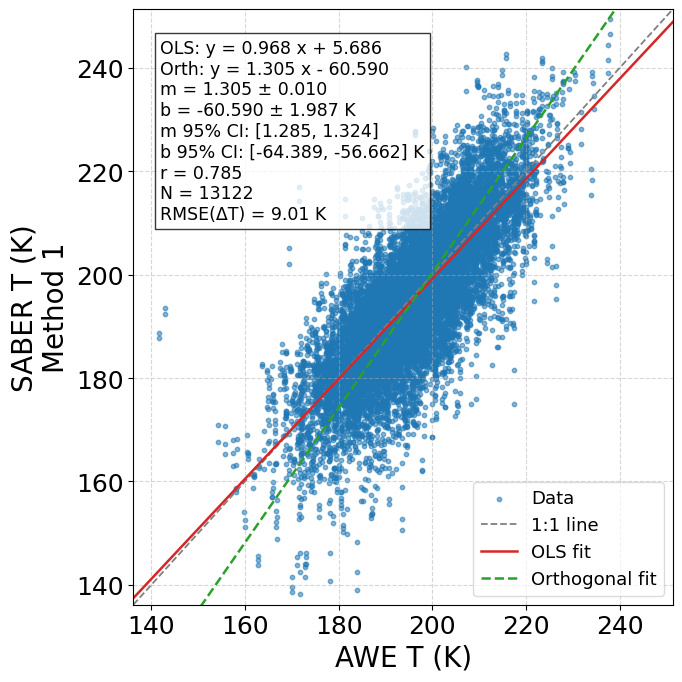

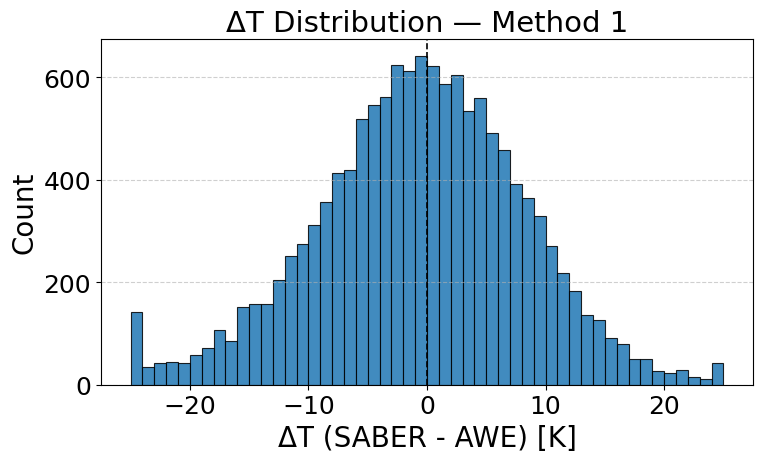

Skipping map for Method 1 because Basemap is unavailable: No module named 'mpl_toolkits.basemap'


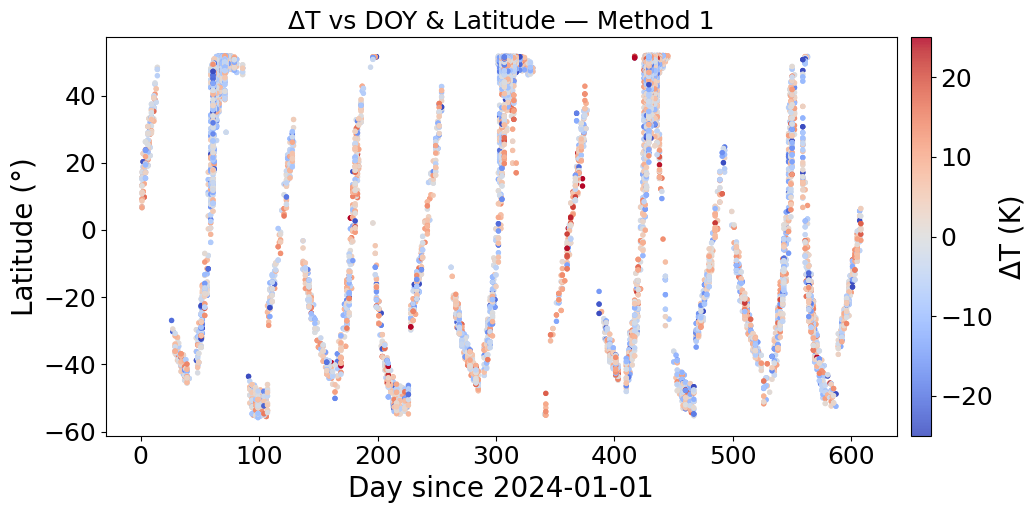

Processing Method 2...


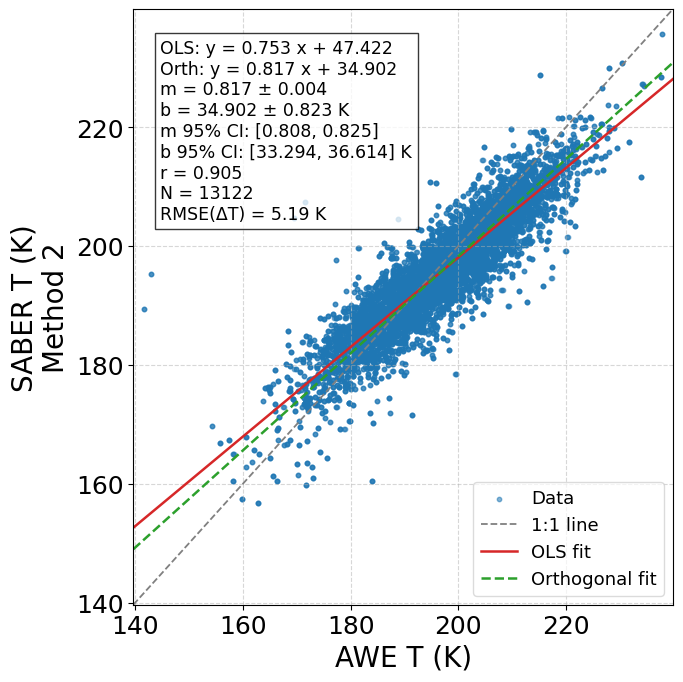

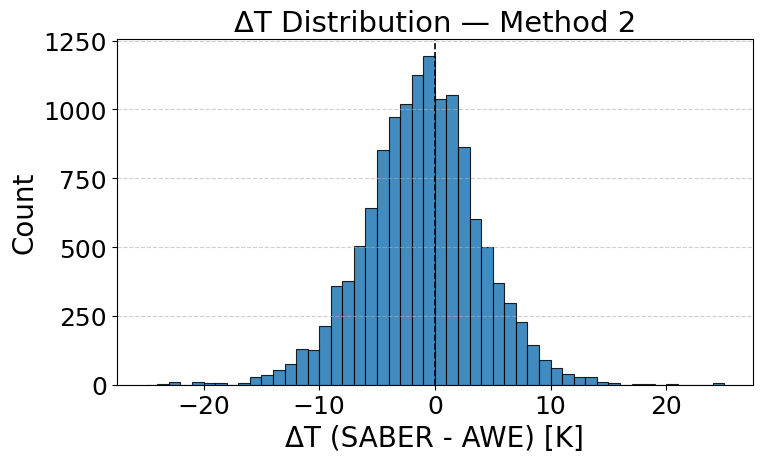

Skipping map for Method 2 because Basemap is unavailable: No module named 'mpl_toolkits.basemap'


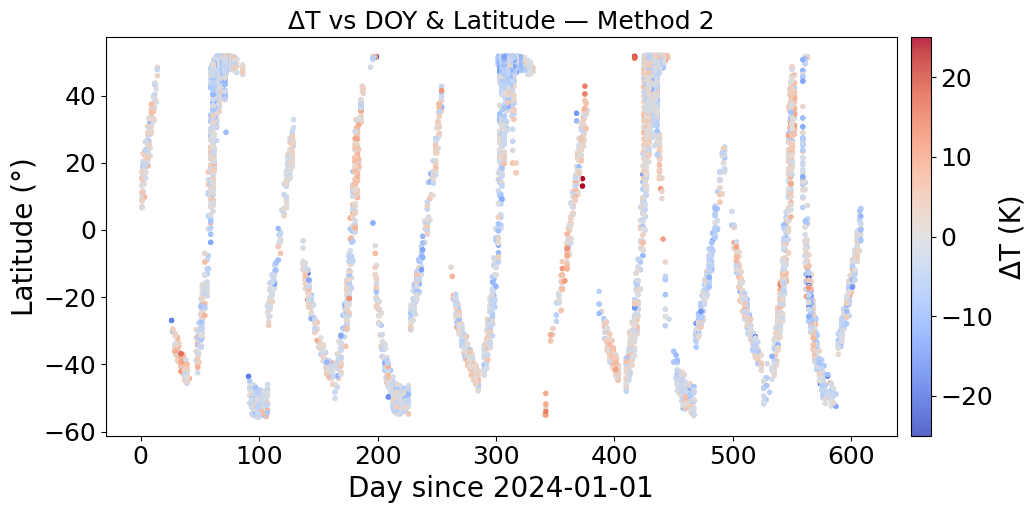

Processing Method 3...


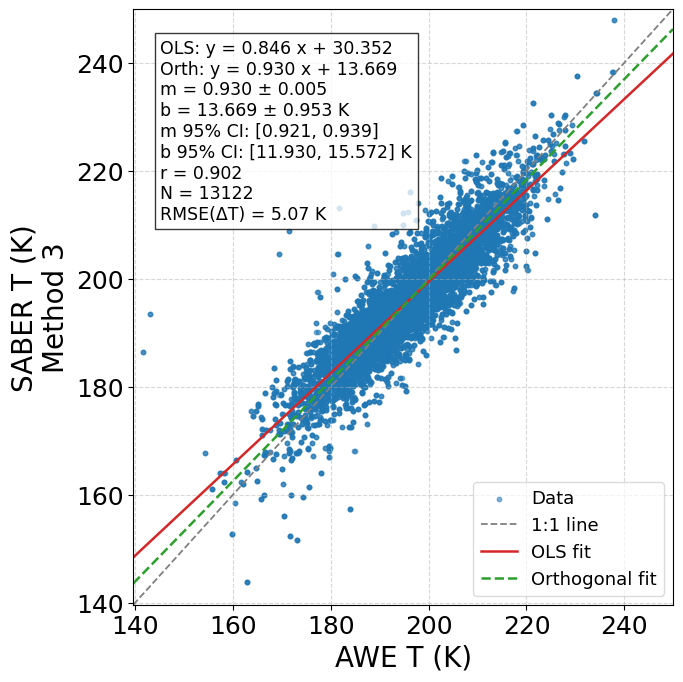

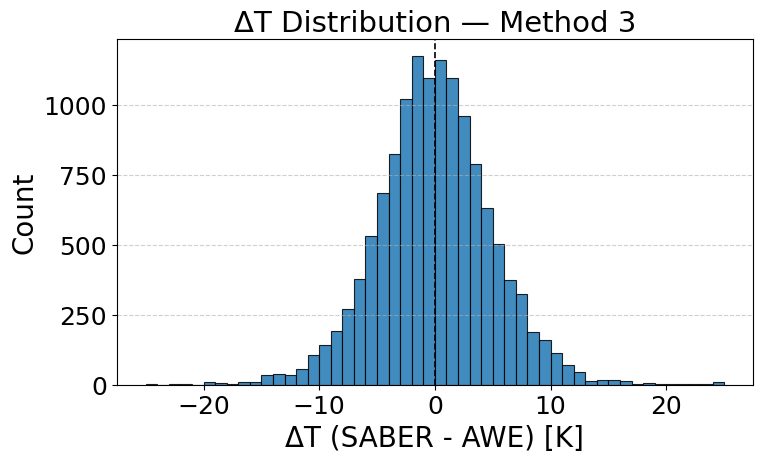

Skipping map for Method 3 because Basemap is unavailable: No module named 'mpl_toolkits.basemap'


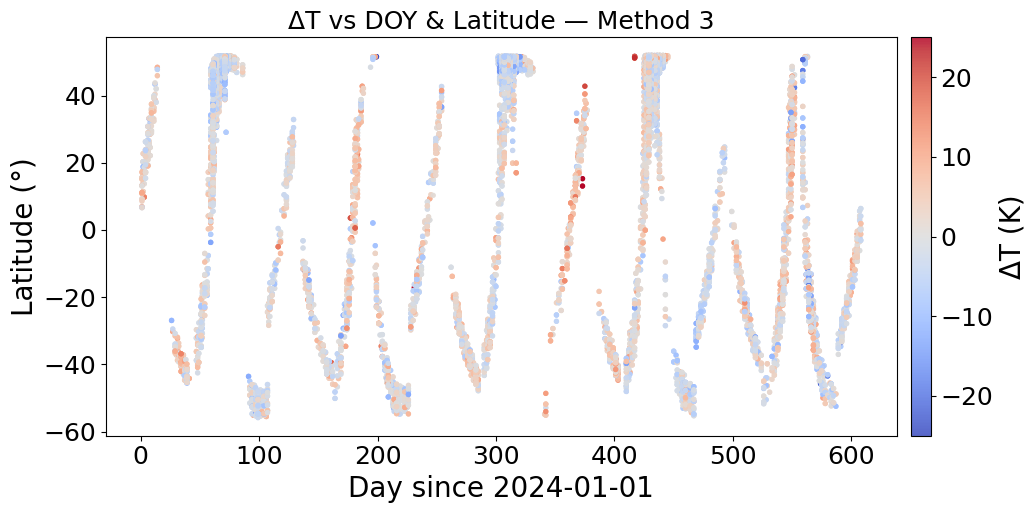

Processing Method 4...


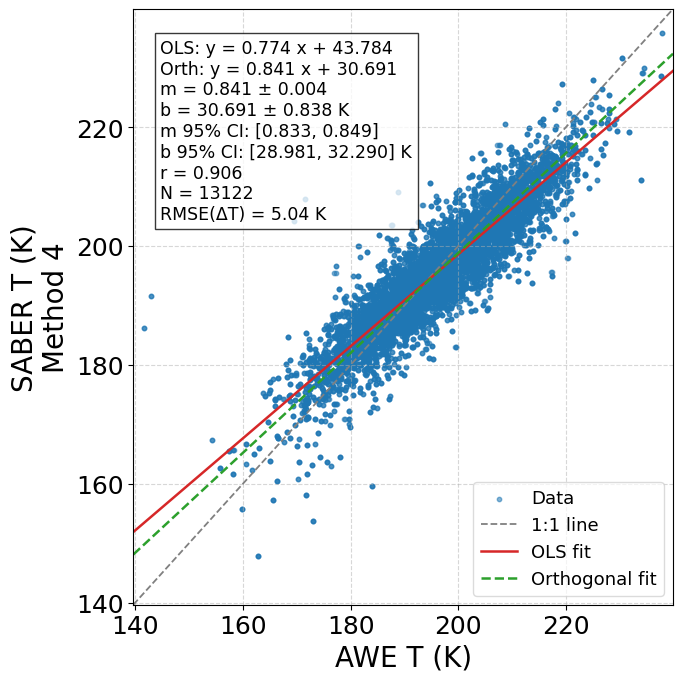

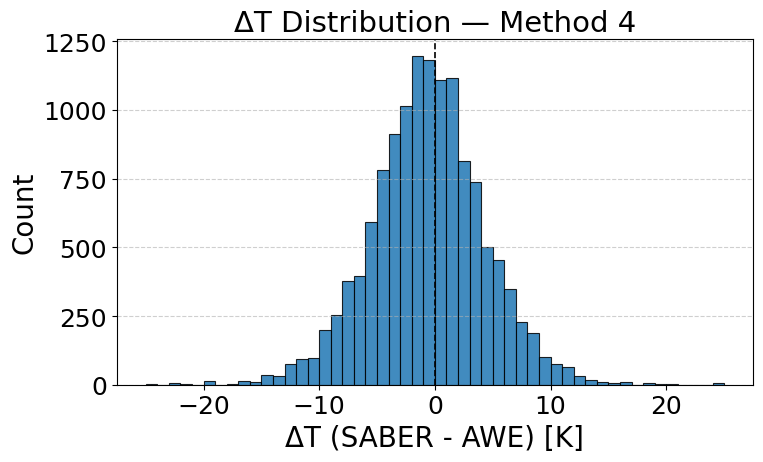

Skipping map for Method 4 because Basemap is unavailable: No module named 'mpl_toolkits.basemap'


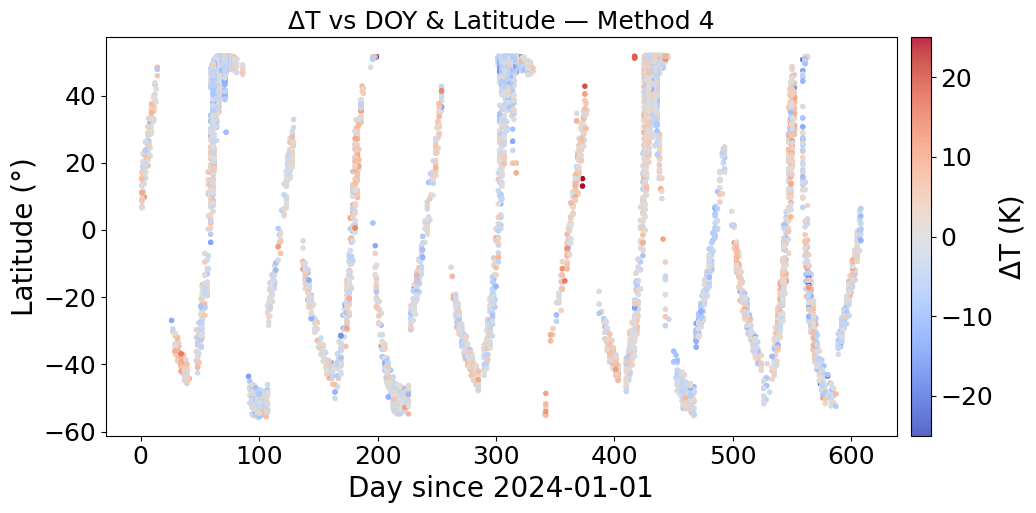

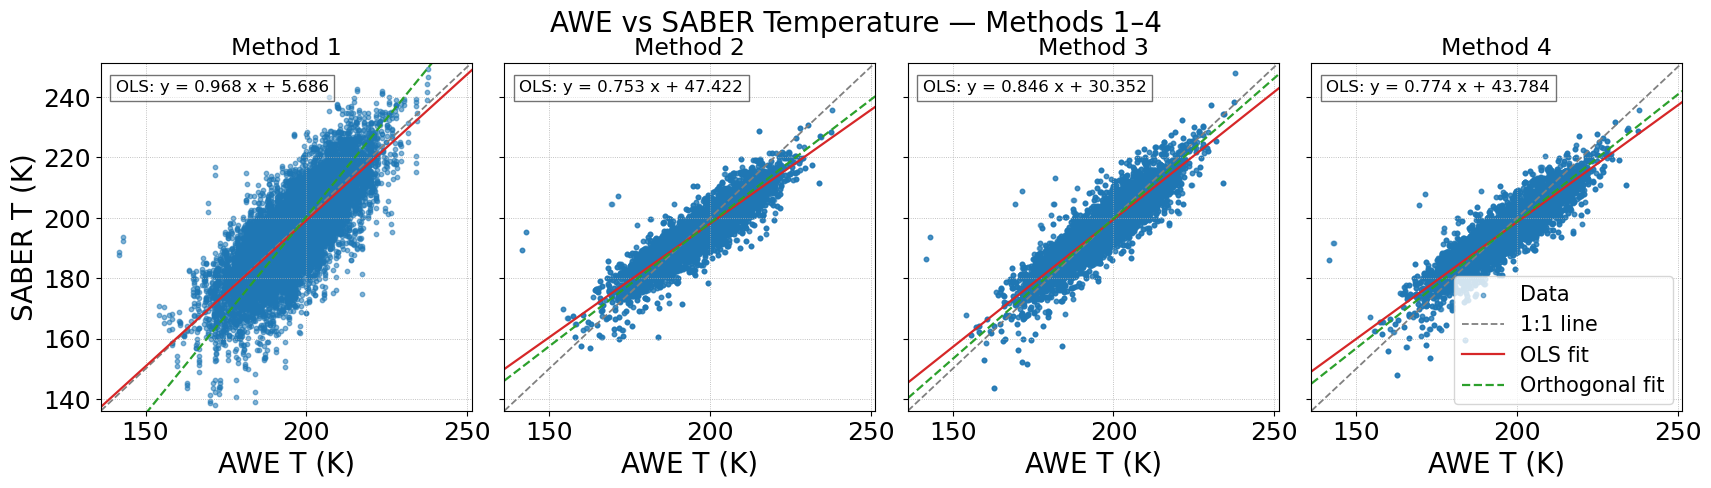

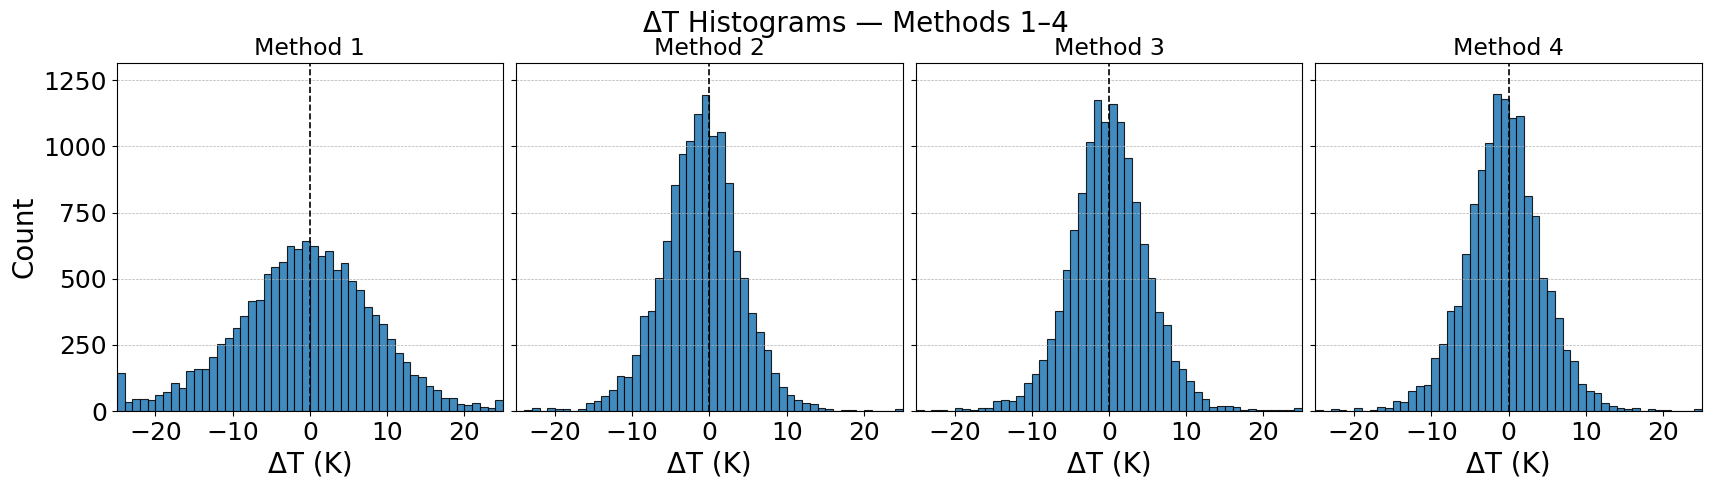


Summary table:


,method,N,mean_dT_K,std_dT_K,median_dT_K,iqr_dT_K,rmse_dT_K,mae_dT_K,r,slope_ols,intercept_ols_K,slope_orth,intercept_orth_K,slope_orth_se,intercept_orth_se_K,slope_orth_ci_low,slope_orth_ci_high,intercept_orth_ci_low_K,intercept_orth_ci_high_K
0,Method 1,13122,-0.696379,8.983066,-0.406977,11.297697,9.009676,6.976055,0.784554,0.967525,5.686262,1.304741,-60.590250,0.010029,1.987229,1.285067,1.323891,-64.388877,-56.662232
1,Method 2,13122,-1.083112,5.073661,-0.997727,6.157267,5.187794,3.951264,0.904609,0.753206,47.421798,0.816906,34.902222,0.004151,0.823050,0.808355,0.825040,33.294225,36.613588
2,Method 3,13122,-0.007165,5.073570,-0.042546,6.090108,5.073382,3.833547,0.902407,0.845534,30.351638,0.930414,13.669346,0.004819,0.953128,0.920710,0.939328,11.930307,15.571558
3,Method 4,13122,-0.621086,5.005178,-0.592362,6.096086,5.043377,3.839349,0.905985,0.774068,43.783666,0.840685,30.690742,0.004234,0.837972,0.832584,0.849222,28.981425,32.290157



✅ All plots saved to: all_methods_plots_large_bootstrap_uncertainty
✅ Summary CSV saved to: all_methods_plots_large_bootstrap_uncertainty/method_fit_summary_with_bootstrap.csv


In [1]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Summary + plots for SABER Methods 1–4
with OLS, orthogonal fits, and bootstrap uncertainty on orthogonal fits.

Adds:
- bootstrap standard error for slope/intercept
- bootstrap 95% confidence intervals
- plot text showing orthogonal fit uncertainty
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from datetime import datetime
import warnings

# --------------------- user settings ---------------------
CSV_PATH_123 = "matched_all_2024_2025_methods_ratio90_clean.csv"
CSV_PATH_M4  = "matched_all_2024_2025_m4shifts_combined_ratio90_clean.csv"

# Common columns
COL_AWE_T = "awe_temp_avg_unfiltered"
COL_LAT   = "saber_lat"
COL_LON   = "saber_lon"
COL_TIME  = "saber_time"

# Plot ranges
DELTA_T_MIN, DELTA_T_MAX = -25.0, 25.0
LAT_MIN, LAT_MAX = -60.0, 60.0

# Bootstrap settings
N_BOOT = 2000
BOOT_RANDOM_SEED = 0

# Methods
METHODS = {
    "Method 1": ("123", "saber_temp",                  "delta_temp_simple_unfiltered_K",         "m1"),
    "Method 2": ("123", "m2_T_K",                      "delta_temp_m2_unfiltered_K",             "m2"),
    "Method 3": ("123", "m3_T_K",                      "delta_temp_m3_unfiltered_K",             "m3"),
    "Method 4": ("m4",  "m4_T_K_shift_m0p75",          "delta_temp_m4_unfiltered_K_shift_m0p75", "m4_m0p75"),
}

# --------------------- style for paper ---------------------
plt.rcParams.update({
    "font.size": 19,
    "axes.labelsize": 20,
    "axes.titlesize": 21,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 23,
    "lines.linewidth": 1.8,
})

# --------------------- helpers ---------------------
def format_line(label, slope, intercept):
    if not np.isfinite(slope) or not np.isfinite(intercept):
        return f"{label}: y = NaN"
    sign = "+" if intercept >= 0 else "-"
    return f"{label}: y = {slope:.3f} x {sign} {abs(intercept):.3f}"

def parse_iso_time_to_datetime(s):
    try:
        return datetime.fromisoformat(str(s))
    except Exception:
        try:
            return pd.to_datetime(s).to_pydatetime()
        except Exception:
            return None

def compute_doy_across_2024_2025(dt):
    if dt is None:
        return np.nan
    if dt.year == 2024:
        return float(dt.timetuple().tm_yday)
    if dt.year == 2025:
        return float(dt.timetuple().tm_yday + 366)
    base = datetime(2024, 1, 1)
    return float((dt - base).days + 1)

def clean_df(df, needed_cols):
    for col in needed_cols + [COL_AWE_T, COL_LAT, COL_LON, COL_TIME]:
        if col not in df.columns:
            raise KeyError(f"Missing column: {col}")
    df = df.copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        dt_list = [parse_iso_time_to_datetime(x) for x in df[COL_TIME].values]
    df["__dt"] = dt_list
    df["__doy"] = [compute_doy_across_2024_2025(d) for d in dt_list]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[COL_AWE_T, COL_LAT, COL_LON, "__doy"] + needed_cols)
    return df

def iqr(x):
    q75 = np.nanpercentile(x, 75)
    q25 = np.nanpercentile(x, 25)
    return q75 - q25

def within(x, thr):
    x = np.asarray(x, dtype=float)
    return np.mean(np.abs(x) <= thr) * 100.0

def orthogonal_fit(x, y):
    """
    Total Least Squares / Orthogonal regression line y = m x + b
    minimizing perpendicular distance.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    x_fit = x[mask]
    y_fit = y[mask]

    x_mean = x_fit.mean()
    y_mean = y_fit.mean()

    # Center data
    X = np.vstack((x_fit - x_mean, y_fit - y_mean)).T

    # SVD
    try:
        _, _, vt = np.linalg.svd(X, full_matrices=False)
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    # normal vector to line
    a, b = vt[-1]

    if np.abs(b) < 1e-12:
        return np.nan, np.nan

    slope = -a / b
    intercept = y_mean - slope * x_mean
    return slope, intercept

def orthogonal_fit_bootstrap(x, y, n_boot=2000, random_seed=0):
    """
    Bootstrap uncertainty for orthogonal fit y = m x + b.

    Returns
    -------
    slope, intercept : best-fit values from full sample
    slope_se, intercept_se : bootstrap standard errors
    slope_ci, intercept_ci : 95% bootstrap confidence intervals
    """
    rng = np.random.default_rng(random_seed)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)

    slope, intercept = orthogonal_fit(x, y)

    slopes = []
    intercepts = []
    n = len(x)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)  # resample with replacement
        xb = x[idx]
        yb = y[idx]
        m, b = orthogonal_fit(xb, yb)
        if np.isfinite(m) and np.isfinite(b):
            slopes.append(m)
            intercepts.append(b)

    slopes = np.asarray(slopes, dtype=float)
    intercepts = np.asarray(intercepts, dtype=float)

    if len(slopes) < 5 or len(intercepts) < 5:
        return slope, intercept, np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)

    slope_se = np.nanstd(slopes, ddof=1)
    intercept_se = np.nanstd(intercepts, ddof=1)

    slope_ci = (np.nanpercentile(slopes, 2.5), np.nanpercentile(slopes, 97.5))
    intercept_ci = (np.nanpercentile(intercepts, 2.5), np.nanpercentile(intercepts, 97.5))

    return slope, intercept, slope_se, intercept_se, slope_ci, intercept_ci

# --------------------- main plotting helper ---------------------
def method_stats_and_plots(df, method_name, saber_col, delta_col, tag, out_dir):
    aweT = df[COL_AWE_T].values
    saberT = df[saber_col].values
    dT = df[delta_col].values
    lat = df[COL_LAT].values
    lon = df[COL_LON].values
    doy = df["__doy"].values

    # Some stats
    n_total = len(df)
    mean_dt = np.nanmean(dT)
    std_dt = np.nanstd(dT, ddof=1)
    med_dt = np.nanmedian(dT)
    iqr_dt = iqr(dT)
    rmse_dt = np.sqrt(np.nanmean((dT)**2))
    mae_dt = np.nanmean(np.abs(dT))

    # Corr + OLS fit
    mask_fit = np.isfinite(aweT) & np.isfinite(saberT)
    if np.sum(mask_fit) >= 2:
        slope_ols, intercept_ols = np.polyfit(aweT[mask_fit], saberT[mask_fit], 1)
        r = np.corrcoef(aweT[mask_fit], saberT[mask_fit])[0, 1]
    else:
        slope_ols, intercept_ols, r = np.nan, np.nan, np.nan

    # Orthogonal / TLS fit + bootstrap uncertainty
    (
        slope_tls, intercept_tls,
        slope_tls_se, intercept_tls_se,
        slope_tls_ci, intercept_tls_ci
    ) = orthogonal_fit_bootstrap(
        aweT, saberT,
        n_boot=N_BOOT,
        random_seed=BOOT_RANDOM_SEED
    )

    # ----- per-method plots -----
    # 1) Scatter AWE vs SABER with 1:1, OLS, TLS, equations
    plt.figure(figsize=(7.2, 7.2))
    plt.scatter(aweT, saberT, s=10, alpha=0.55, label="Data")

    lo = min(np.nanmin(aweT), np.nanmin(saberT)) - 2
    hi = max(np.nanmax(aweT), np.nanmax(saberT)) + 2

    # 1:1 line
    plt.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.3, label="1:1 line")

    x_line = np.linspace(lo, hi, 200)

    # OLS fit line
    if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
        y_ols = slope_ols * x_line + intercept_ols
        plt.plot(x_line, y_ols, color="tab:red", linewidth=1.8, label="OLS fit")

    # TLS fit line
    if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
        y_tls = slope_tls * x_line + intercept_tls
        plt.plot(x_line, y_tls, color="tab:green", linestyle="--", linewidth=1.8, label="Orthogonal fit")

    # Equation text
    eq_lines = []
    if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
        eq_lines.append(format_line("OLS", slope_ols, intercept_ols))
    if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
        eq_lines.append(format_line("Orth", slope_tls, intercept_tls))
        if np.isfinite(slope_tls_se):
            eq_lines.append(f"m = {slope_tls:.3f} ± {slope_tls_se:.3f}")
        if np.isfinite(intercept_tls_se):
            eq_lines.append(f"b = {intercept_tls:.3f} ± {intercept_tls_se:.3f} K")
        if np.all(np.isfinite(slope_tls_ci)):
            eq_lines.append(f"m 95% CI: [{slope_tls_ci[0]:.3f}, {slope_tls_ci[1]:.3f}]")
        if np.all(np.isfinite(intercept_tls_ci)):
            eq_lines.append(f"b 95% CI: [{intercept_tls_ci[0]:.3f}, {intercept_tls_ci[1]:.3f}] K")
    if np.isfinite(r):
        eq_lines.append(f"r = {r:.3f}")
    eq_lines.append(f"N = {n_total}")
    eq_lines.append(f"RMSE(ΔT) = {rmse_dt:.2f} K")

    if eq_lines:
        eq_text = "\n".join(eq_lines)
        plt.text(
            0.05, 0.95, eq_text,
            transform=plt.gca().transAxes,
            fontsize=12.5,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.78, edgecolor="black")
        )

    plt.xlabel("AWE T (K)")
    plt.ylabel(f"SABER T (K)\n{method_name}")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="lower right", fontsize=13, framealpha=0.7)
    plt.tight_layout()
    plt.savefig(out_dir / f"scatter_awe_vs_saber_{tag}.png", dpi=300)
    plt.show()
    plt.close()

    # 2) Histogram
    plt.figure(figsize=(8, 5))
    bins = np.arange(DELTA_T_MIN, DELTA_T_MAX + 1, 1.0)
    plt.hist(
        np.clip(dT, DELTA_T_MIN, DELTA_T_MAX),
        bins=bins, edgecolor="black", linewidth=0.8, alpha=0.85
    )
    plt.axvline(0, color="k", linestyle="--", linewidth=1.2)
    plt.xlabel("ΔT (SABER - AWE) [K]")
    plt.ylabel("Count")
    plt.title(f"ΔT Distribution — {method_name}")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(out_dir / f"hist_deltaT_{tag}.png", dpi=300)
    plt.show()
    plt.close()

    # 3) Map (optional Basemap)
    try:
        from mpl_toolkits.basemap import Basemap
        sel = (lat >= LAT_MIN) & (lat <= LAT_MAX) & np.isfinite(dT)
        plt.figure(figsize=(12, 5.2))
        m = Basemap(
            projection="cyl",
            llcrnrlat=LAT_MIN, urcrnrlat=LAT_MAX,
            llcrnrlon=-180, urcrnrlon=180, resolution="c"
        )
        m.drawcoastlines(linewidth=0.6)
        m.drawparallels(np.arange(-60, 61, 15), labels=[1, 0, 0, 0], fontsize=13)
        m.drawmeridians(np.arange(-180, 181, 30), labels=[0, 0, 0, 1], fontsize=13)
        norm = TwoSlopeNorm(vmin=DELTA_T_MIN, vcenter=0, vmax=DELTA_T_MAX)
        sc = m.scatter(
            lon[sel], lat[sel], c=dT[sel], s=8,
            cmap="coolwarm", norm=norm, alpha=0.85
        )
        cb = plt.colorbar(sc, shrink=0.85, pad=0.03)
        cb.set_label("ΔT (K)", fontsize=15)
        plt.title(f"ΔT Map (lat -60..60) — {method_name}", fontsize=18)
        plt.tight_layout()
        plt.savefig(out_dir / f"map_deltaT_{tag}_basemap_rect.png", dpi=300)
        plt.show()
        plt.close()
    except Exception as e:
        print(f"Skipping map for {method_name} because Basemap is unavailable: {e}")

    # 4) DOY vs Latitude
    sel2 = (lat >= LAT_MIN) & (lat <= LAT_MAX) & np.isfinite(dT)
    plt.figure(figsize=(11, 5.5))
    norm = TwoSlopeNorm(vmin=DELTA_T_MIN, vcenter=0.0, vmax=DELTA_T_MAX)
    sc = plt.scatter(
        doy[sel2], lat[sel2],
        c=dT[sel2], s=8, cmap="coolwarm", norm=norm, alpha=0.85
    )
    plt.xlabel("Day since 2024-01-01")
    plt.ylabel("Latitude (°)")
    plt.colorbar(sc, pad=0.015, label="ΔT (K)")
    plt.title(f"ΔT vs DOY & Latitude — {method_name}", fontsize=18)
    plt.tight_layout()
    plt.savefig(out_dir / f"doy_lat_deltaT_{tag}.png", dpi=300)
    plt.show()
    plt.close()

    # summary row for table / print
    summary = {
        "method": method_name,
        "N": n_total,
        "mean_dT_K": mean_dt,
        "std_dT_K": std_dt,
        "median_dT_K": med_dt,
        "iqr_dT_K": iqr_dt,
        "rmse_dT_K": rmse_dt,
        "mae_dT_K": mae_dt,
        "r": r,
        "slope_ols": slope_ols,
        "intercept_ols_K": intercept_ols,
        "slope_orth": slope_tls,
        "intercept_orth_K": intercept_tls,
        "slope_orth_se": slope_tls_se,
        "intercept_orth_se_K": intercept_tls_se,
        "slope_orth_ci_low": slope_tls_ci[0],
        "slope_orth_ci_high": slope_tls_ci[1],
        "intercept_orth_ci_low_K": intercept_tls_ci[0],
        "intercept_orth_ci_high_K": intercept_tls_ci[1],
    }

    return summary, aweT, saberT, dT, slope_ols, intercept_ols, slope_tls, intercept_tls

# --------------------- combined 1×4 plots ---------------------
def make_combined_scatter(awe_saber_dict, fit_dict_ols, fit_dict_tls, out_dir):
    methods = ["Method 1", "Method 2", "Method 3", "Method 4"]

    fig, axs = plt.subplots(
        1, 4, figsize=(17, 4.5),
        constrained_layout=True, sharex=True, sharey=True
    )

    mins, maxs = [], []
    for name in methods:
        aweT, saberT = awe_saber_dict[name]
        mins.append(np.nanmin([aweT, saberT]))
        maxs.append(np.nanmax([aweT, saberT]))
    lo, hi = float(min(mins)) - 2, float(max(maxs)) + 2

    legend_handles = []
    legend_labels = []

    for ax, name in zip(axs, methods):
        aweT, saberT = awe_saber_dict[name]
        slope_ols, intercept_ols = fit_dict_ols[name]
        slope_tls, intercept_tls = fit_dict_tls[name]

        h_sc = ax.scatter(aweT, saberT, s=10, alpha=0.55)
        if not legend_handles:
            legend_handles.append(h_sc)
            legend_labels.append("Data")

        h_11 = ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.3)[0]
        if len(legend_handles) == 1:
            legend_handles.append(h_11)
            legend_labels.append("1:1 line")

        x_line = np.linspace(lo, hi, 200)

        if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
            y_ols = slope_ols * x_line + intercept_ols
            h_ols = ax.plot(x_line, y_ols, color="tab:red", linewidth=1.6)[0]
            if len(legend_handles) == 2:
                legend_handles.append(h_ols)
                legend_labels.append("OLS fit")

        if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
            y_tls = slope_tls * x_line + intercept_tls
            h_tls = ax.plot(x_line, y_tls, color="tab:green", linestyle="--", linewidth=1.6)[0]
            if len(legend_handles) == 3:
                legend_handles.append(h_tls)
                legend_labels.append("Orthogonal fit")

        if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
            eq_text = format_line("OLS", slope_ols, intercept_ols)
            ax.text(
                0.04, 0.95, eq_text,
                transform=ax.transAxes,
                fontsize=12,
                verticalalignment="top",
                bbox=dict(facecolor="white", alpha=0.55, edgecolor="black")
            )

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_title(name, fontsize=17)
        ax.set_xlabel("AWE T (K)")
        if ax is axs[0]:
            ax.set_ylabel("SABER T (K)")
        ax.grid(True, linestyle=":", linewidth=0.6)

    fig.legend(
        legend_handles, legend_labels,
        loc="lower right",
        bbox_to_anchor=(0.987, 0.15),
        fontsize=15,
        framealpha=0.8
    )

    fig.suptitle("AWE vs SABER Temperature — Methods 1–4", fontsize=20, y=1.05)
    fig.savefig(out_dir / "scatter_all_methods.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def make_combined_hist(dT_dict, out_dir):
    methods = ["Method 1", "Method 2", "Method 3", "Method 4"]
    bins = np.arange(DELTA_T_MIN, DELTA_T_MAX + 1, 1.0)

    max_count = 0
    for name in methods:
        dT = dT_dict[name]
        clipped = np.clip(dT, DELTA_T_MIN, DELTA_T_MAX)
        counts, _ = np.histogram(clipped, bins=bins)
        max_count = max(max_count, counts.max())

    ymax = int(np.ceil(max_count * 1.10))

    fig, axs = plt.subplots(1, 4, figsize=(17, 4.5), constrained_layout=True, sharey=True)
    for ax, name in zip(axs, methods):
        dT = dT_dict[name]
        ax.hist(
            np.clip(dT, DELTA_T_MIN, DELTA_T_MAX), bins=bins,
            edgecolor="black", linewidth=0.8, alpha=0.85
        )
        ax.axvline(0, color="k", linestyle="--", linewidth=1.2)
        ax.set_xlim(DELTA_T_MIN, DELTA_T_MAX)
        ax.set_ylim(0, ymax)
        ax.set_title(name, fontsize=17)
        ax.set_xlabel("ΔT (K)")
        if ax is axs[0]:
            ax.set_ylabel("Count")
        ax.grid(axis="y", linestyle="--", linewidth=0.5)

    fig.suptitle("ΔT Histograms — Methods 1–4", fontsize=20, y=1.05)
    fig.savefig(out_dir / "hist_all_methods.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# --------------------- main ---------------------
def run_all_methods():
    csv_path_123 = Path(CSV_PATH_123)
    csv_path_m4 = Path(CSV_PATH_M4)

    df123 = pd.read_csv(csv_path_123)
    dfm4 = pd.read_csv(csv_path_m4)

    out_dir = csv_path_123.parent / "all_methods_plots_large_bootstrap_uncertainty"
    out_dir.mkdir(exist_ok=True, parents=True)

    awe_saber_dict = {}
    dT_dict = {}
    fit_dict_ols = {}
    fit_dict_tls = {}
    summaries = []

    for method_name, (which_csv, saber_col, delta_col, tag) in METHODS.items():
        df_raw = df123 if which_csv == "123" else dfm4
        df = clean_df(df_raw, [saber_col, delta_col])

        print(f"Processing {method_name}...")

        summary, aweT, saberT, dT, slope_ols, intercept_ols, slope_tls, intercept_tls = method_stats_and_plots(
            df, method_name, saber_col, delta_col, tag, out_dir
        )

        summaries.append(summary)
        awe_saber_dict[method_name] = (aweT, saberT)
        dT_dict[method_name] = dT
        fit_dict_ols[method_name] = (slope_ols, intercept_ols)
        fit_dict_tls[method_name] = (slope_tls, intercept_tls)

    make_combined_scatter(awe_saber_dict, fit_dict_ols, fit_dict_tls, out_dir)
    make_combined_hist(dT_dict, out_dir)

    summary_df = pd.DataFrame(summaries)
    summary_csv = out_dir / "method_fit_summary_with_bootstrap.csv"
    summary_df.to_csv(summary_csv, index=False)

    print("\nSummary table:")
    display(summary_df)

    print(f"\n✅ All plots saved to: {out_dir}")
    print(f"✅ Summary CSV saved to: {summary_csv}")

# Run
run_all_methods()

## Formal Comparison

Common matched pairs shared by Methods 2–4: 13122

Pairwise bootstrap comparison among Methods 2–4


,Comparison,N_common,ΔSlope,ΔSlope_SE,ΔSlope_CI_low,ΔSlope_CI_high,Slope_significant,ΔIntercept_K,ΔIntercept_SE_K,ΔIntercept_CI_low_K,ΔIntercept_CI_high_K,Intercept_significant,ΔRMSE_K,ΔRMSE_SE_K,ΔRMSE_CI_low_K,ΔRMSE_CI_high_K,RMSE_significant
0,Method 2 - Method 3,13122,-0.1135,0.0026,-0.1188,-0.1085,True,21.2329,0.5161,20.2456,22.2923,True,0.1144,0.0308,0.0567,0.1741,True
1,Method 2 - Method 4,13122,-0.0238,0.0021,-0.0279,-0.0198,True,4.2115,0.4048,3.4417,5.0143,True,0.1444,0.0234,0.0999,0.1917,True
2,Method 3 - Method 4,13122,0.0897,0.0019,0.0862,0.0934,True,-17.0214,0.3623,-17.7465,-16.3209,True,0.0300,0.0212,-0.0117,0.0731,False



Saved pairwise comparison table to:
all_methods_plots_orth_only_bootstrap_clean/summary_pairwise_methods_2_3_4_bootstrap_differences.csv


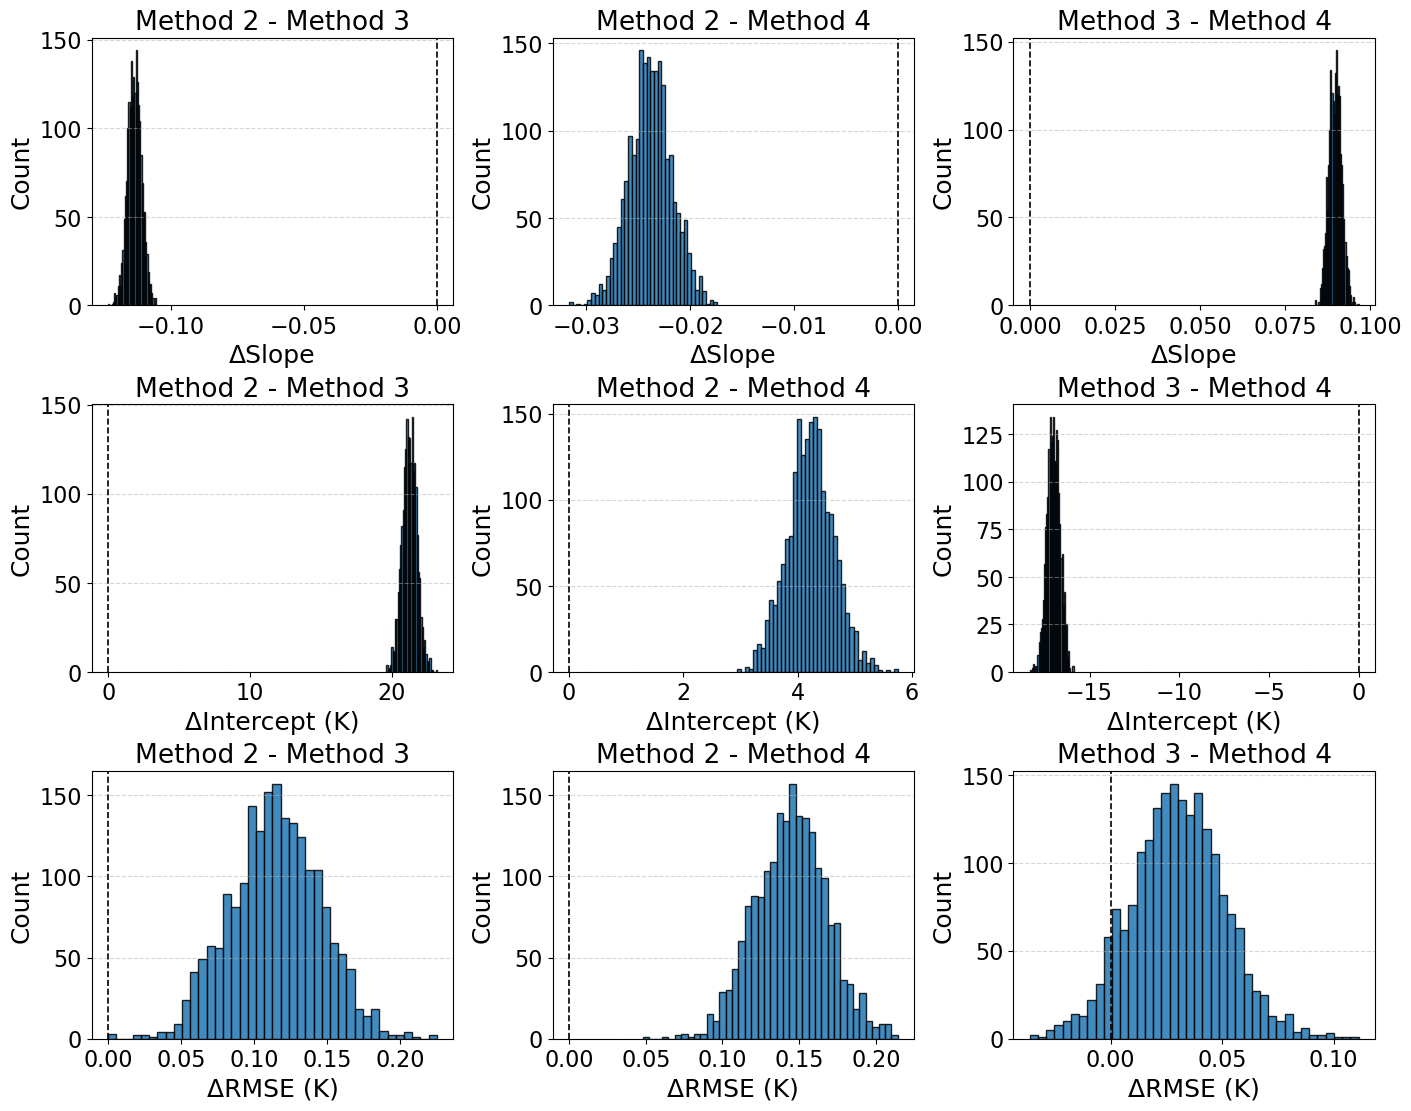

Saved bootstrap-difference histograms to:
all_methods_plots_orth_only_bootstrap_clean/pairwise_methods_2_3_4_bootstrap_difference_histograms.png


In [10]:
# %% Formal statistical comparison among SABER Methods 2–4
# Pairwise bootstrap comparison of:
#   - orthogonal-fit slope
#   - orthogonal-fit intercept
#   - RMSE
#
# Interpretation:
#   If the 95% CI of the pairwise difference includes 0,
#   the difference is not statistically significant.

from itertools import combinations

# -----------------------------
# Settings
# -----------------------------
COMPARE_METHODS = {
    "Method 2": ("123", "m2_T_K"),
    "Method 3": ("123", "m3_T_K"),
    "Method 4": ("m4",  "m4_T_K_shift_m0p75"),
}

COMPARE_N_BOOT = 2000
COMPARE_RANDOM_SEED = 42

# Keys used to align the same matched AWE-SABER pairs across methods
MERGE_KEYS = [COL_TIME, COL_LAT, COL_LON, COL_AWE_T]

# -----------------------------
# Helper functions
# -----------------------------
def rmse(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) == 0:
        return np.nan
    return np.sqrt(np.mean((y[mask] - x[mask])**2))

def build_method_df(df_raw, saber_col, method_name):
    needed = MERGE_KEYS + [saber_col]
    df = clean_df(df_raw, [saber_col])

    # Keep only needed columns and rename SABER column to method-specific name
    out = df[MERGE_KEYS + [saber_col]].copy()
    out = out.rename(columns={saber_col: f"{method_name}_SABER"})
    return out

def bootstrap_pairwise_method_differences(df_common, method_a, method_b, n_boot=2000, random_seed=0):
    """
    Bootstrap pairwise differences using the same resampled matched pairs
    for both methods, so the comparison is paired and fair.

    Returns differences defined as:
        delta = (method_a) - (method_b)
    for slope, intercept, and RMSE.
    """
    rng = np.random.default_rng(random_seed)

    x = df_common[COL_AWE_T].to_numpy(dtype=float)
    ya = df_common[f"{method_a}_SABER"].to_numpy(dtype=float)
    yb = df_common[f"{method_b}_SABER"].to_numpy(dtype=float)

    mask = np.isfinite(x) & np.isfinite(ya) & np.isfinite(yb)
    x  = x[mask]
    ya = ya[mask]
    yb = yb[mask]

    n = len(x)
    if n < 3:
        raise ValueError(f"Not enough common matched pairs for {method_a} vs {method_b}")

    # Full-sample estimates
    m_a, b_a = orthogonal_fit(x, ya)
    m_b, b_b = orthogonal_fit(x, yb)
    rmse_a = rmse(x, ya)
    rmse_b = rmse(x, yb)

    full_delta_slope = m_a - m_b
    full_delta_intercept = b_a - b_b
    full_delta_rmse = rmse_a - rmse_b

    # Bootstrap distributions of pairwise differences
    delta_slopes = []
    delta_intercepts = []
    delta_rmses = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)

        xb  = x[idx]
        yab = ya[idx]
        ybb = yb[idx]

        m_a_b, b_a_b = orthogonal_fit(xb, yab)
        m_b_b, b_b_b = orthogonal_fit(xb, ybb)
        rmse_a_b = rmse(xb, yab)
        rmse_b_b = rmse(xb, ybb)

        if np.isfinite(m_a_b) and np.isfinite(m_b_b):
            delta_slopes.append(m_a_b - m_b_b)
        if np.isfinite(b_a_b) and np.isfinite(b_b_b):
            delta_intercepts.append(b_a_b - b_b_b)
        if np.isfinite(rmse_a_b) and np.isfinite(rmse_b_b):
            delta_rmses.append(rmse_a_b - rmse_b_b)

    delta_slopes = np.asarray(delta_slopes, dtype=float)
    delta_intercepts = np.asarray(delta_intercepts, dtype=float)
    delta_rmses = np.asarray(delta_rmses, dtype=float)

    def summarize(arr, estimate):
        if len(arr) < 5:
            return {
                "estimate": estimate,
                "se": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "significant": np.nan,
            }
        ci_low = np.nanpercentile(arr, 2.5)
        ci_high = np.nanpercentile(arr, 97.5)
        return {
            "estimate": estimate,
            "se": np.nanstd(arr, ddof=1),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "significant": not (ci_low <= 0 <= ci_high),
        }

    slope_stats = summarize(delta_slopes, full_delta_slope)
    intercept_stats = summarize(delta_intercepts, full_delta_intercept)
    rmse_stats = summarize(delta_rmses, full_delta_rmse)

    return {
        "N_common": n,
        "delta_slope": slope_stats,
        "delta_intercept": intercept_stats,
        "delta_rmse": rmse_stats,
        "delta_slope_samples": delta_slopes,
        "delta_intercept_samples": delta_intercepts,
        "delta_rmse_samples": delta_rmses,
    }

# -----------------------------
# Build common merged dataframe for Methods 2–4
# -----------------------------
method_frames = {}

for method_name, (which_csv, saber_col) in COMPARE_METHODS.items():
    df_raw = df123 if which_csv == "123" else dfm4
    method_frames[method_name] = build_method_df(df_raw, saber_col, method_name)

df_common = method_frames["Method 2"].merge(
    method_frames["Method 3"],
    on=MERGE_KEYS,
    how="inner"
).merge(
    method_frames["Method 4"],
    on=MERGE_KEYS,
    how="inner"
)

print(f"Common matched pairs shared by Methods 2–4: {len(df_common)}")

# -----------------------------
# Pairwise comparisons
# -----------------------------
rows = []
pairwise_results = {}

for method_a, method_b in combinations(COMPARE_METHODS.keys(), 2):
    result = bootstrap_pairwise_method_differences(
        df_common=df_common,
        method_a=method_a,
        method_b=method_b,
        n_boot=COMPARE_N_BOOT,
        random_seed=COMPARE_RANDOM_SEED,
    )
    pairwise_results[(method_a, method_b)] = result

    rows.append({
        "Comparison": f"{method_a} - {method_b}",
        "N_common": result["N_common"],

        "ΔSlope": result["delta_slope"]["estimate"],
        "ΔSlope_SE": result["delta_slope"]["se"],
        "ΔSlope_CI_low": result["delta_slope"]["ci_low"],
        "ΔSlope_CI_high": result["delta_slope"]["ci_high"],
        "Slope_significant": result["delta_slope"]["significant"],

        "ΔIntercept_K": result["delta_intercept"]["estimate"],
        "ΔIntercept_SE_K": result["delta_intercept"]["se"],
        "ΔIntercept_CI_low_K": result["delta_intercept"]["ci_low"],
        "ΔIntercept_CI_high_K": result["delta_intercept"]["ci_high"],
        "Intercept_significant": result["delta_intercept"]["significant"],

        "ΔRMSE_K": result["delta_rmse"]["estimate"],
        "ΔRMSE_SE_K": result["delta_rmse"]["se"],
        "ΔRMSE_CI_low_K": result["delta_rmse"]["ci_low"],
        "ΔRMSE_CI_high_K": result["delta_rmse"]["ci_high"],
        "RMSE_significant": result["delta_rmse"]["significant"],
    })

pairwise_df = pd.DataFrame(rows)

print("\nPairwise bootstrap comparison among Methods 2–4")
display(pairwise_df.round(4))

# Save table
pairwise_csv = OUT_DIR / "summary_pairwise_methods_2_3_4_bootstrap_differences.csv"
pairwise_df.to_csv(pairwise_csv, index=False)
print(f"\nSaved pairwise comparison table to:\n{pairwise_csv}")

# -----------------------------
# Optional quick-look histograms of bootstrap differences
# -----------------------------
fig, axs = plt.subplots(3, 3, figsize=(14, 11), constrained_layout=True)

pairs = list(combinations(COMPARE_METHODS.keys(), 2))
metrics = [
    ("delta_slope_samples", "ΔSlope"),
    ("delta_intercept_samples", "ΔIntercept (K)"),
    ("delta_rmse_samples", "ΔRMSE (K)"),
]

for col_idx, (method_a, method_b) in enumerate(pairs):
    result = pairwise_results[(method_a, method_b)]

    for row_idx, (sample_key, xlabel) in enumerate(metrics):
        ax = axs[row_idx, col_idx]
        vals = result[sample_key]

        ax.hist(vals, bins=40, edgecolor="black", alpha=0.85)
        ax.axvline(0, color="k", linestyle="--", linewidth=1.2)
        ax.set_title(f"{method_a} - {method_b}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.grid(axis="y", linestyle="--", alpha=0.5)

hist_path = OUT_DIR / "pairwise_methods_2_3_4_bootstrap_difference_histograms.png"
plt.savefig(hist_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved bootstrap-difference histograms to:\n{hist_path}")

## Plot fits, save stats to .csv

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Summary + plots for SABER Methods 1–4 (paper version, with OLS and orthogonal fits)

- OLS fit: SABER vs AWE (minimize vertical distance dy)
- Orthogonal fit (Total Least Squares, minimize perpendicular distance)
All plots saved to one folder, larger text for visibility on paper.

Also writes a CSV:
  summary_overall_all_methods.csv

with, for each method:
  - N
  - mean_K, std_K, median_K, IQR_K, RMSE_K, MAE_K
  - corr_AWE_SABER
  - slope_OLS_SABER_vs_AWE, intercept_OLS
  - slope_TLS_SABER_vs_AWE, intercept_TLS
  - pct_|dT|<=3K      (fraction within ±3 K)
  - pct_|dT|<=10K     (fraction within ±10 K)
  - pct_|dT|>15K      (fraction with |ΔT| > 15 K)
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from datetime import datetime
import warnings

# --------------------- user settings ---------------------
CSV_PATH_123 = "matched_all_2024_2025_methods_ratio90_clean.csv"
CSV_PATH_M4  = "matched_all_2024_2025_m4shifts_combined_ratio90_clean.csv"

# Common columns
COL_AWE_T = "awe_temp_avg_unfiltered"
COL_LAT   = "saber_lat"
COL_LON   = "saber_lon"
COL_TIME  = "saber_time"

# Plot ranges
DELTA_T_MIN, DELTA_T_MAX = -25.0, 25.0
LAT_MIN, LAT_MAX = -60.0, 60.0

# Methods
METHODS = {
    "Method 1": ("123", "saber_temp",                    "delta_temp_simple_unfiltered_K",           "m1"),
    "Method 2": ("123", "m2_T_K",                        "delta_temp_m2_unfiltered_K",               "m2"),
    "Method 3": ("123", "m3_T_K",                        "delta_temp_m3_unfiltered_K",               "m3"),
    "Method 4": ("m4",  "m4_T_K_shift_m0p75",            "delta_temp_m4_unfiltered_K_shift_m0p75",   "m4_m0p75"),
}

# --------------------- style for paper ---------------------
plt.rcParams.update({
    "font.size": 19,
    "axes.labelsize": 20,
    "axes.titlesize": 21,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 23,
    "lines.linewidth": 1.8,
})


# --------------------- helpers ---------------------
def format_line(label, slope, intercept):
    """
    Return 'label: y = m x ± b' with correct sign on b.
    """
    if not np.isfinite(slope) or not np.isfinite(intercept):
        return f"{label}: y = NaN"
    sign = "+" if intercept >= 0 else "-"
    return f"{label}: y = {slope:.3f} x {sign} {abs(intercept):.3f}"


def parse_iso_time_to_datetime(s):
    try:
        return datetime.fromisoformat(str(s))
    except Exception:
        try:
            return pd.to_datetime(s).to_pydatetime()
        except Exception:
            return None

def compute_doy_across_2024_2025(dt):
    if dt is None:
        return np.nan
    if dt.year == 2024:
        return float(dt.timetuple().tm_yday)
    if dt.year == 2025:
        return float(dt.timetuple().tm_yday + 366)
    base = datetime(2024, 1, 1)
    return float((dt - base).days + 1)

def clean_df(df, needed_cols):
    for col in needed_cols + [COL_AWE_T, COL_LAT, COL_LON, COL_TIME]:
        if col not in df.columns:
            raise KeyError(f"Missing column: {col}")
    df = df.copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        dt_list = [parse_iso_time_to_datetime(x) for x in df[COL_TIME].values]
    df["__dt"]  = dt_list
    df["__doy"] = [compute_doy_across_2024_2025(d) for d in dt_list]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[COL_AWE_T, COL_LAT, COL_LON, "__doy"] + needed_cols)
    return df

def iqr(x):
    q75 = np.nanpercentile(x, 75)
    q25 = np.nanpercentile(x, 25)
    return q75 - q25

def within(x, thr):
    x = np.asarray(x, dtype=float)
    return np.mean(np.abs(x) <= thr) * 100.0

def orthogonal_fit(x, y):
    """
    Total Least Squares / Orthogonal regression line y = m x + b
    minimizing perpendicular distance.

    Returns slope, intercept. If it fails, returns (nan, nan).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    x_fit = x[mask]
    y_fit = y[mask]

    x_mean = x_fit.mean()
    y_mean = y_fit.mean()

    # Center data
    X = np.vstack((x_fit - x_mean, y_fit - y_mean)).T  # shape (N, 2)

    # SVD
    try:
        _, _, vt = np.linalg.svd(X, full_matrices=False)
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    # The direction of smallest variance (normal to line)
    a, b = vt[-1]  # normal vector (a, b) so that a*(x-x_mean) + b*(y-y_mean) = 0

    if np.abs(b) < 1e-12:
        # Vertical line case; cannot express as y = m x + c
        return np.nan, np.nan

    slope = -a / b
    intercept = y_mean - slope * x_mean
    return slope, intercept


# --------------------- main plotting + stats helper ---------------------
def method_stats_and_plots(df, method_name, saber_col, delta_col, tag, out_dir):
    aweT   = df[COL_AWE_T].values
    saberT = df[saber_col].values
    dT     = df[delta_col].values
    lat    = df[COL_LAT].values
    lon    = df[COL_LON].values
    doy    = df["__doy"].values

    # --------------------- statistics (overall) ---------------------
    n_total = len(df)
    mean_dt = np.nanmean(dT)
    std_dt  = np.nanstd(dT, ddof=1)
    med_dt  = np.nanmedian(dT)
    iqr_dt  = iqr(dT)
    rmse_dt = np.sqrt(np.nanmean((dT)**2))
    mae_dt  = np.nanmean(np.abs(dT))

    # Corr + OLS fit
    mask_fit = np.isfinite(aweT) & np.isfinite(saberT)
    if np.sum(mask_fit) >= 2:
        slope_ols, intercept_ols = np.polyfit(aweT[mask_fit], saberT[mask_fit], 1)
        r = np.corrcoef(aweT[mask_fit], saberT[mask_fit])[0, 1]
    else:
        slope_ols, intercept_ols, r = np.nan, np.nan, np.nan

    # Orthogonal / TLS fit
    slope_tls, intercept_tls = orthogonal_fit(aweT, saberT)

    # Percent metrics for Titus
    p_within_3  = within(dT, 3.0)                # |ΔT| ≤ 3 K
    p_within_10 = within(dT, 10.0)               # |ΔT| ≤ 10 K
    p_above_15  = 100.0 * np.mean(np.abs(dT) > 15.0)  # |ΔT| > 15 K

    # Row for combined summary CSV
    overall_row = {
        "method": method_name,
        "tag": tag,
        "N": n_total,
        "mean_K": mean_dt,
        "std_K": std_dt,
        "median_K": med_dt,
        "IQR_K": iqr_dt,
        "RMSE_K": rmse_dt,
        "MAE_K": mae_dt,
        "corr_AWE_SABER": r,
        "slope_OLS_SABER_vs_AWE": slope_ols,
        "intercept_OLS": intercept_ols,
        "slope_TLS_SABER_vs_AWE": slope_tls,
        "intercept_TLS": intercept_tls,
        "pct_|dT|<=3K": p_within_3,
        "pct_|dT|<=10K": p_within_10,
        "pct_|dT|>15K": p_above_15,
    }

    # --------------------- per-method plots ---------------------
    # 1) Scatter AWE vs SABER with 1:1, OLS, TLS, equations
    plt.figure(figsize=(7.2, 7.2))
    plt.scatter(aweT, saberT, s=10, alpha=0.55, label="Data")

    lo = min(np.nanmin(aweT), np.nanmin(saberT)) - 2
    hi = max(np.nanmax(aweT), np.nanmax(saberT)) + 2

    # 1:1 line
    plt.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.3, label="1:1 line")

    x_line = np.linspace(lo, hi, 200)

    # OLS fit line
    if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
        y_ols = slope_ols * x_line + intercept_ols
        plt.plot(x_line, y_ols, color="tab:red", linewidth=1.8, label="OLS fit")

    # TLS (orthogonal) fit line
    if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
        y_tls = slope_tls * x_line + intercept_tls
        plt.plot(x_line, y_tls, color="tab:green", linestyle="--", linewidth=1.8, label="Orthogonal fit")

    # Equation text (with correct ± b)
    eq_lines = []
    if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
        eq_lines.append(format_line("OLS", slope_ols, intercept_ols))
    if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
        eq_lines.append(format_line("Orth", slope_tls, intercept_tls))
    if np.isfinite(r):
        eq_lines.append(f"r = {r:.3f}")

    if eq_lines:
        eq_text = "\n".join(eq_lines)
        plt.text(
            0.05, 0.95, eq_text,
            transform=plt.gca().transAxes,
            fontsize=15,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
        )

    plt.xlabel("AWE T (K)")
    plt.ylabel(f"SABER T (K)\n{method_name}")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.grid(True, linestyle="--", alpha=0.5)

    # Legend in lower-right to avoid equation
    plt.legend(loc="lower right", fontsize=14, framealpha=0.7)
    plt.tight_layout()
    plt.savefig(out_dir / f"scatter_awe_vs_saber_{tag}.png", dpi=300)
    plt.close()

    # 2) Histogram
    plt.figure(figsize=(8, 5))
    bins = np.arange(DELTA_T_MIN, DELTA_T_MAX + 1, 1.0)
    plt.hist(
        np.clip(dT, DELTA_T_MIN, DELTA_T_MAX),
        bins=bins, edgecolor="black", linewidth=0.8, alpha=0.85
    )
    plt.axvline(0, color="k", linestyle="--", linewidth=1.2)
    plt.xlabel("ΔT (SABER - AWE) [K]")
    plt.ylabel("Count")
    plt.title(f"ΔT Distribution — {method_name}")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(out_dir / f"hist_deltaT_{tag}.png", dpi=300)
    plt.close()

    # 3) Map (optional Basemap)
    try:
        from mpl_toolkits.basemap import Basemap
        sel = (lat >= LAT_MIN) & (lat <= LAT_MAX) & np.isfinite(dT)
        plt.figure(figsize=(12, 5.2))
        m = Basemap(
            projection="cyl",
            llcrnrlat=LAT_MIN, urcrnrlat=LAT_MAX,
            llcrnrlon=-180, urcrnrlon=180, resolution="c"
        )
        m.drawcoastlines(linewidth=0.6)
        m.drawparallels(np.arange(-60, 61, 15), labels=[1, 0, 0, 0], fontsize=13)
        m.drawmeridians(np.arange(-180, 181, 30), labels=[0, 0, 0, 1], fontsize=13)
        norm = TwoSlopeNorm(vmin=DELTA_T_MIN, vcenter=0, vmax=DELTA_T_MAX)
        sc = m.scatter(
            lon[sel], lat[sel], c=dT[sel], s=8,
            cmap="coolwarm", norm=norm, alpha=0.85
        )
        cb = plt.colorbar(sc, shrink=0.85, pad=0.03)
        cb.set_label("ΔT (K)", fontsize=15)
        plt.title(f"ΔT Map (lat -60..60) — {method_name}", fontsize=18)
        plt.tight_layout()
        plt.savefig(out_dir / f"map_deltaT_{tag}_basemap_rect.png", dpi=300)
        plt.close()
    except Exception:
        pass

    # 4) DOY vs Latitude
    sel2 = (lat >= LAT_MIN) & (lat <= LAT_MAX) & np.isfinite(dT) & np.isfinite(doy)
    plt.figure(figsize=(11, 5.5))
    norm = TwoSlopeNorm(vmin=DELTA_T_MIN, vcenter=0.0, vmax=DELTA_T_MAX)
    sc = plt.scatter(
        doy[sel2], lat[sel2],
        c=dT[sel2], s=8, cmap="coolwarm", norm=norm, alpha=0.85
    )
    plt.xlabel("Day since 2024-01-01")
    plt.ylabel("Latitude (°)")
    plt.colorbar(sc, pad=0.015, label="ΔT (K)")
    plt.title(f"ΔT vs DOY & Latitude — {method_name}", fontsize=18)
    plt.tight_layout()
    plt.savefig(out_dir / f"doy_lat_deltaT_{tag}.png", dpi=300)
    plt.close()

    # Return for combined plots + summary row
    return aweT, saberT, dT, slope_ols, intercept_ols, slope_tls, intercept_tls, overall_row


# --------------------- combined 1×4 plots ---------------------
def make_combined_scatter(awe_saber_dict, fit_dict_ols, fit_dict_tls, out_dir):
    methods = ["Method 1", "Method 2", "Method 3", "Method 4"]

    fig, axs = plt.subplots(
        1, 4, figsize=(17, 4.5),
        constrained_layout=True, sharex=True, sharey=True
    )

    # Determine global min/max
    mins, maxs = [], []
    for name in methods:
        aweT, saberT = awe_saber_dict[name]
        mins.append(np.nanmin([aweT, saberT]))
        maxs.append(np.nanmax([aweT, saberT]))
    lo, hi = float(min(mins)) - 2, float(max(maxs)) + 2

    legend_handles = []
    legend_labels  = []

    for ax, name in zip(axs, methods):
        aweT, saberT = awe_saber_dict[name]
        slope_ols, intercept_ols = fit_dict_ols[name]
        slope_tls, intercept_tls = fit_dict_tls[name]

        # Scatter
        h_sc = ax.scatter(aweT, saberT, s=10, alpha=0.55)
        if not legend_handles:
            legend_handles.append(h_sc)
            legend_labels.append("Data")

        # 1:1 line
        h_11 = ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.3)[0]
        if len(legend_handles) == 1:
            legend_handles.append(h_11)
            legend_labels.append("1:1 line")

        x_line = np.linspace(lo, hi, 200)

        # OLS fit
        if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
            y_ols = slope_ols * x_line + intercept_ols
            h_ols = ax.plot(x_line, y_ols, color="tab:red", linewidth=1.6)[0]
            if len(legend_handles) == 2:
                legend_handles.append(h_ols)
                legend_labels.append("OLS fit")

        # TLS fit
        if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
            y_tls = slope_tls * x_line + intercept_tls
            h_tls = ax.plot(x_line, y_tls, color="tab:green", linestyle="--", linewidth=1.6)[0]
            if len(legend_handles) == 3:
                legend_handles.append(h_tls)
                legend_labels.append("Orthogonal fit")

        # Show OLS equation inside panel (with proper ±)
        if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
            eq_text = format_line("OLS", slope_ols, intercept_ols)
            ax.text(
                0.04, 0.95, eq_text,
                transform=ax.transAxes,
                fontsize=12,
                verticalalignment="top",
                bbox=dict(facecolor="white", alpha=0.55, edgecolor="black")
            )

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_title(name, fontsize=17)
        ax.set_xlabel("AWE T (K)")
        if ax is axs[0]:
            ax.set_ylabel("SABER T (K)")
        ax.grid(True, linestyle=":", linewidth=0.6)

    # Shared legend at bottom-right of the whole figure
    fig.legend(
        legend_handles, legend_labels,
        loc="lower right",
        bbox_to_anchor=(0.987, 0.15),
        fontsize=15,
        framealpha=0.8
    )

    fig.suptitle("AWE vs SABER Temperature — Methods 1–4", fontsize=20, y=1.05)
    fig.savefig(out_dir / "scatter_all_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


def make_combined_hist(dT_dict, out_dir):
    methods = ["Method 1", "Method 2", "Method 3", "Method 4"]
    bins = np.arange(DELTA_T_MIN, DELTA_T_MAX + 1, 1.0)

    max_count = 0
    for name in methods:
        dT = dT_dict[name]
        clipped = np.clip(dT, DELTA_T_MIN, DELTA_T_MAX)
        counts, _ = np.histogram(clipped, bins=bins)
        max_count = max(max_count, counts.max())

    ymax = int(np.ceil(max_count * 1.10))

    fig, axs = plt.subplots(1, 4, figsize=(17, 4.5), constrained_layout=True, sharey=True)
    for ax, name in zip(axs, methods):
        dT = dT_dict[name]
        ax.hist(
            np.clip(dT, DELTA_T_MIN, DELTA_T_MAX), bins=bins,
            edgecolor="black", linewidth=0.8, alpha=0.85
        )
        ax.axvline(0, color="k", linestyle="--", linewidth=1.2)
        ax.set_xlim(DELTA_T_MIN, DELTA_T_MAX)
        ax.set_ylim(0, ymax)
        ax.set_title(name, fontsize=17)
        ax.set_xlabel("ΔT (K)")
        if ax is axs[0]:
            ax.set_ylabel("Count")
        ax.grid(axis="y", linestyle="--", linewidth=0.5)

    fig.suptitle("ΔT Histograms — Methods 1–4", fontsize=20, y=1.05)
    fig.savefig(out_dir / "hist_all_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


# --------------------- main ---------------------
def run_all_methods():
    csv_path_123 = Path(CSV_PATH_123)
    csv_path_m4  = Path(CSV_PATH_M4)
    df123 = pd.read_csv(csv_path_123)
    dfm4  = pd.read_csv(csv_path_m4)

    out_dir = csv_path_123.parent / "all_methods_plots_large"
    out_dir.mkdir(exist_ok=True, parents=True)

    awe_saber_dict = {}
    dT_dict = {}
    fit_dict_ols = {}
    fit_dict_tls = {}
    overall_rows = []

    for method_name, (which_csv, saber_col, delta_col, tag) in METHODS.items():
        df_raw = df123 if which_csv == "123" else dfm4
        df = clean_df(df_raw, [saber_col, delta_col])
        print(f"Processing {method_name}...")
        aweT, saberT, dT, slope_ols, intercept_ols, slope_tls, intercept_tls, overall_row = method_stats_and_plots(
            df, method_name, saber_col, delta_col, tag, out_dir
        )
        awe_saber_dict[method_name] = (aweT, saberT)
        dT_dict[method_name] = dT
        fit_dict_ols[method_name] = (slope_ols, intercept_ols)
        fit_dict_tls[method_name] = (slope_tls, intercept_tls)
        overall_rows.append(overall_row)

    # Combined overall CSV for all methods (this is what Titus needs)
    overall_df = pd.DataFrame(overall_rows)
    overall_df.to_csv(out_dir / "summary_overall_all_methods.csv", index=False)

    make_combined_scatter(awe_saber_dict, fit_dict_ols, fit_dict_tls, out_dir)
    make_combined_hist(dT_dict, out_dir)
    print(f"\n✅ All plots and summary_overall_all_methods.csv saved to: {out_dir}")


# Run
if __name__ == "__main__":
    run_all_methods()


Processing Method 1...
Processing Method 2...
Processing Method 3...
Processing Method 4...

✅ All plots and summary_overall_all_methods.csv saved to: all_methods_plots_large


## Orth Fit Only, Add Uncertainty and Follow-up Table. 

In [4]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Summary + plots for SABER Methods 1–4 (paper version, orthogonal fit only)

Changes from previous version:
- No OLS fit is computed or plotted
- Scatter plots show:
    * 1:1 line
    * Orthogonal fit line
    * Orthogonal fit equation
    * Orthogonal slope ± bootstrap SE
    * correlation coefficient r
- Saves detailed uncertainty values in CSV
- Includes a tiny follow-up table cell at the end

Outputs:
- one folder with plots
- summary_overall_all_methods_orth_only_bootstrap.csv
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from datetime import datetime
import warnings

# --------------------- user settings ---------------------
CSV_PATH_123 = "matched_all_2024_2025_methods_ratio90_clean.csv"
CSV_PATH_M4  = "matched_all_2024_2025_m4shifts_combined_ratio90_clean.csv"

# Common columns
COL_AWE_T = "awe_temp_avg_unfiltered"
COL_LAT   = "saber_lat"
COL_LON   = "saber_lon"
COL_TIME  = "saber_time"

# Plot ranges
DELTA_T_MIN, DELTA_T_MAX = -25.0, 25.0
LAT_MIN, LAT_MAX = -60.0, 60.0

# Bootstrap settings
N_BOOT = 2000
BOOT_RANDOM_SEED = 0

# Methods
METHODS = {
    "Method 1": ("123", "saber_temp",                    "delta_temp_simple_unfiltered_K",           "m1"),
    "Method 2": ("123", "m2_T_K",                        "delta_temp_m2_unfiltered_K",               "m2"),
    "Method 3": ("123", "m3_T_K",                        "delta_temp_m3_unfiltered_K",               "m3"),
    "Method 4": ("m4",  "m4_T_K_shift_m0p75",            "delta_temp_m4_unfiltered_K_shift_m0p75",   "m4_m0p75"),
}

# --------------------- style for paper ---------------------
plt.rcParams.update({
    "font.size": 19,
    "axes.labelsize": 20,
    "axes.titlesize": 21,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 23,
    "lines.linewidth": 1.8,
})

# --------------------- helpers ---------------------
def format_line(label, slope, intercept):
    if not np.isfinite(slope) or not np.isfinite(intercept):
        return f"{label}: y = NaN"
    sign = "+" if intercept >= 0 else "-"
    return f"{label}: y = {slope:.3f} x {sign} {abs(intercept):.3f}"

def parse_iso_time_to_datetime(s):
    try:
        return datetime.fromisoformat(str(s))
    except Exception:
        try:
            return pd.to_datetime(s).to_pydatetime()
        except Exception:
            return None

def compute_doy_across_2024_2025(dt):
    if dt is None:
        return np.nan
    if dt.year == 2024:
        return float(dt.timetuple().tm_yday)
    if dt.year == 2025:
        return float(dt.timetuple().tm_yday + 366)
    base = datetime(2024, 1, 1)
    return float((dt - base).days + 1)

def clean_df(df, needed_cols):
    for col in needed_cols + [COL_AWE_T, COL_LAT, COL_LON, COL_TIME]:
        if col not in df.columns:
            raise KeyError(f"Missing column: {col}")
    df = df.copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        dt_list = [parse_iso_time_to_datetime(x) for x in df[COL_TIME].values]
    df["__dt"]  = dt_list
    df["__doy"] = [compute_doy_across_2024_2025(d) for d in dt_list]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[COL_AWE_T, COL_LAT, COL_LON, "__doy"] + needed_cols)
    return df

def iqr(x):
    q75 = np.nanpercentile(x, 75)
    q25 = np.nanpercentile(x, 25)
    return q75 - q25

def within(x, thr):
    x = np.asarray(x, dtype=float)
    return np.mean(np.abs(x) <= thr) * 100.0

def orthogonal_fit(x, y):
    """
    Total Least Squares / Orthogonal regression line y = m x + b
    minimizing perpendicular distance.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    x_fit = x[mask]
    y_fit = y[mask]

    x_mean = x_fit.mean()
    y_mean = y_fit.mean()

    X = np.vstack((x_fit - x_mean, y_fit - y_mean)).T

    try:
        _, _, vt = np.linalg.svd(X, full_matrices=False)
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    a, b = vt[-1]

    if np.abs(b) < 1e-12:
        return np.nan, np.nan

    slope = -a / b
    intercept = y_mean - slope * x_mean
    return slope, intercept

def orthogonal_fit_bootstrap(x, y, n_boot=2000, random_seed=0):
    """
    Bootstrap uncertainty for orthogonal fit y = m x + b.

    Returns
    -------
    slope, intercept : best-fit values from full sample
    slope_se, intercept_se : bootstrap standard errors
    slope_ci, intercept_ci : 95% bootstrap confidence intervals
    """
    rng = np.random.default_rng(random_seed)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)

    slope, intercept = orthogonal_fit(x, y)

    slopes = []
    intercepts = []
    n = len(x)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)   # resample matched pairs with replacement
        xb = x[idx]
        yb = y[idx]
        m, b = orthogonal_fit(xb, yb)
        if np.isfinite(m) and np.isfinite(b):
            slopes.append(m)
            intercepts.append(b)

    slopes = np.asarray(slopes, dtype=float)
    intercepts = np.asarray(intercepts, dtype=float)

    if len(slopes) < 5 or len(intercepts) < 5:
        return slope, intercept, np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)

    slope_se = np.nanstd(slopes, ddof=1)
    intercept_se = np.nanstd(intercepts, ddof=1)

    slope_ci = (np.nanpercentile(slopes, 2.5), np.nanpercentile(slopes, 97.5))
    intercept_ci = (np.nanpercentile(intercepts, 2.5), np.nanpercentile(intercepts, 97.5))

    return slope, intercept, slope_se, intercept_se, slope_ci, intercept_ci

# --------------------- main plotting + stats helper ---------------------
def method_stats_and_plots(df, method_name, saber_col, delta_col, tag, out_dir):
    aweT   = df[COL_AWE_T].values
    saberT = df[saber_col].values
    dT     = df[delta_col].values
    lat    = df[COL_LAT].values
    lon    = df[COL_LON].values
    doy    = df["__doy"].values

    # overall stats
    n_total = len(df)
    mean_dt = np.nanmean(dT)
    std_dt  = np.nanstd(dT, ddof=1)
    med_dt  = np.nanmedian(dT)
    iqr_dt  = iqr(dT)
    rmse_dt = np.sqrt(np.nanmean((dT)**2))
    mae_dt  = np.nanmean(np.abs(dT))

    mask_fit = np.isfinite(aweT) & np.isfinite(saberT)
    if np.sum(mask_fit) >= 2:
        r = np.corrcoef(aweT[mask_fit], saberT[mask_fit])[0, 1]
    else:
        r = np.nan

    (
        slope_tls, intercept_tls,
        slope_tls_se, intercept_tls_se,
        slope_tls_ci, intercept_tls_ci
    ) = orthogonal_fit_bootstrap(
        aweT, saberT,
        n_boot=N_BOOT,
        random_seed=BOOT_RANDOM_SEED
    )

    p_within_3  = within(dT, 3.0)
    p_within_10 = within(dT, 10.0)
    p_above_15  = 100.0 * np.mean(np.abs(dT) > 15.0)

    overall_row = {
        "method": method_name,
        "tag": tag,
        "N": n_total,
        "mean_K": mean_dt,
        "std_K": std_dt,
        "median_K": med_dt,
        "IQR_K": iqr_dt,
        "RMSE_K": rmse_dt,
        "MAE_K": mae_dt,
        "corr_AWE_SABER": r,
        "slope_TLS_SABER_vs_AWE": slope_tls,
        "intercept_TLS": intercept_tls,
        "slope_TLS_bootstrap_SE": slope_tls_se,
        "intercept_TLS_bootstrap_SE": intercept_tls_se,
        "slope_TLS_CI_low_95": slope_tls_ci[0],
        "slope_TLS_CI_high_95": slope_tls_ci[1],
        "intercept_TLS_CI_low_95": intercept_tls_ci[0],
        "intercept_TLS_CI_high_95": intercept_tls_ci[1],
        "pct_|dT|<=3K": p_within_3,
        "pct_|dT|<=10K": p_within_10,
        "pct_|dT|>15K": p_above_15,
    }

    # 1) Scatter
    plt.figure(figsize=(7.2, 7.2))
    plt.scatter(aweT, saberT, s=10, alpha=0.55, label="Data")

    lo = min(np.nanmin(aweT), np.nanmin(saberT)) - 2
    hi = max(np.nanmax(aweT), np.nanmax(saberT)) + 2

    plt.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.3, label="1:1 line")

    x_line = np.linspace(lo, hi, 200)

    if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
        y_tls = slope_tls * x_line + intercept_tls
        plt.plot(x_line, y_tls, color="tab:green", linestyle="--", linewidth=1.8, label="Orthogonal fit")

    eq_lines = []
    if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
        eq_lines.append(format_line("Orth", slope_tls, intercept_tls))
    if np.isfinite(slope_tls_se):
        eq_lines.append(f"m = {slope_tls:.3f} ± {slope_tls_se:.3f}")
    if np.isfinite(r):
        eq_lines.append(f"r = {r:.3f}")

    if eq_lines:
        eq_text = "\n".join(eq_lines)
        plt.text(
            0.05, 0.95, eq_text,
            transform=plt.gca().transAxes,
            fontsize=13,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
        )

    plt.xlabel("AWE T (K)")
    plt.ylabel(f"SABER T (K)\n{method_name}")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="lower right", fontsize=14, framealpha=0.7)
    plt.tight_layout()
    plt.savefig(out_dir / f"scatter_awe_vs_saber_{tag}.png", dpi=300)
    plt.close()

    # 2) Histogram
    plt.figure(figsize=(8, 5))
    bins = np.arange(DELTA_T_MIN, DELTA_T_MAX + 1, 1.0)
    plt.hist(
        np.clip(dT, DELTA_T_MIN, DELTA_T_MAX),
        bins=bins, edgecolor="black", linewidth=0.8, alpha=0.85
    )
    plt.axvline(0, color="k", linestyle="--", linewidth=1.2)
    plt.xlabel("ΔT (SABER - AWE) [K]")
    plt.ylabel("Count")
    plt.title(f"ΔT Distribution — {method_name}")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(out_dir / f"hist_deltaT_{tag}.png", dpi=300)
    plt.close()

    # 3) Map
    try:
        from mpl_toolkits.basemap import Basemap
        sel = (lat >= LAT_MIN) & (lat <= LAT_MAX) & np.isfinite(dT)
        plt.figure(figsize=(12, 5.2))
        m = Basemap(
            projection="cyl",
            llcrnrlat=LAT_MIN, urcrnrlat=LAT_MAX,
            llcrnrlon=-180, urcrnrlon=180, resolution="c"
        )
        m.drawcoastlines(linewidth=0.6)
        m.drawparallels(np.arange(-60, 61, 15), labels=[1, 0, 0, 0], fontsize=13)
        m.drawmeridians(np.arange(-180, 181, 30), labels=[0, 0, 0, 1], fontsize=13)
        norm = TwoSlopeNorm(vmin=DELTA_T_MIN, vcenter=0, vmax=DELTA_T_MAX)
        sc = m.scatter(
            lon[sel], lat[sel], c=dT[sel], s=8,
            cmap="coolwarm", norm=norm, alpha=0.85
        )
        cb = plt.colorbar(sc, shrink=0.85, pad=0.03)
        cb.set_label("ΔT (K)", fontsize=15)
        plt.title(f"ΔT Map (lat -60..60) — {method_name}", fontsize=18)
        plt.tight_layout()
        plt.savefig(out_dir / f"map_deltaT_{tag}_basemap_rect.png", dpi=300)
        plt.close()
    except Exception:
        pass

    # 4) DOY vs Latitude
    sel2 = (lat >= LAT_MIN) & (lat <= LAT_MAX) & np.isfinite(dT) & np.isfinite(doy)
    plt.figure(figsize=(11, 5.5))
    norm = TwoSlopeNorm(vmin=DELTA_T_MIN, vcenter=0.0, vmax=DELTA_T_MAX)
    sc = plt.scatter(
        doy[sel2], lat[sel2],
        c=dT[sel2], s=8, cmap="coolwarm", norm=norm, alpha=0.85
    )
    plt.xlabel("Day since 2024-01-01")
    plt.ylabel("Latitude (°)")
    plt.colorbar(sc, pad=0.015, label="ΔT (K)")
    plt.title(f"ΔT vs DOY & Latitude — {method_name}", fontsize=18)
    plt.tight_layout()
    plt.savefig(out_dir / f"doy_lat_deltaT_{tag}.png", dpi=300)
    plt.close()

    return aweT, saberT, dT, slope_tls, intercept_tls, overall_row

# --------------------- combined plots ---------------------
def make_combined_scatter(awe_saber_dict, fit_dict_tls, fit_unc_dict, out_dir):
    methods = ["Method 1", "Method 2", "Method 3", "Method 4"]

    fig, axs = plt.subplots(
        1, 4, figsize=(17, 4.5),
        constrained_layout=True, sharex=True, sharey=True
    )

    mins, maxs = [], []
    for name in methods:
        aweT, saberT = awe_saber_dict[name]
        mins.append(np.nanmin([aweT, saberT]))
        maxs.append(np.nanmax([aweT, saberT]))
    lo, hi = float(min(mins)) - 2, float(max(maxs)) + 2

    legend_handles = []
    legend_labels  = []

    for ax, name in zip(axs, methods):
        aweT, saberT = awe_saber_dict[name]
        slope_tls, intercept_tls = fit_dict_tls[name]
        slope_tls_se = fit_unc_dict[name]["slope_se"]

        h_sc = ax.scatter(aweT, saberT, s=10, alpha=0.55)
        if not legend_handles:
            legend_handles.append(h_sc)
            legend_labels.append("Data")

        h_11 = ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.3)[0]
        if len(legend_handles) == 1:
            legend_handles.append(h_11)
            legend_labels.append("1:1 line")

        x_line = np.linspace(lo, hi, 200)

        if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
            y_tls = slope_tls * x_line + intercept_tls
            h_tls = ax.plot(x_line, y_tls, color="tab:green", linestyle="--", linewidth=1.6)[0]
            if len(legend_handles) == 2:
                legend_handles.append(h_tls)
                legend_labels.append("Orthogonal fit")

        text_lines = []
        if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
            text_lines.append(format_line("Orth", slope_tls, intercept_tls))
        if np.isfinite(slope_tls_se):
            text_lines.append(f"m = {slope_tls:.3f} ± {slope_tls_se:.3f}")

        if text_lines:
            ax.text(
                0.04, 0.95, "\n".join(text_lines),
                transform=ax.transAxes,
                fontsize=11,
                verticalalignment="top",
                bbox=dict(facecolor="white", alpha=0.55, edgecolor="black")
            )

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_title(name, fontsize=17)
        ax.set_xlabel("AWE T (K)")
        if ax is axs[0]:
            ax.set_ylabel("SABER T (K)")
        ax.grid(True, linestyle=":", linewidth=0.6)

    fig.legend(
        legend_handles, legend_labels,
        loc="lower right",
        bbox_to_anchor=(0.987, 0.15),
        fontsize=15,
        framealpha=0.8
    )

    fig.suptitle("AWE vs SABER Temperature — Methods 1–4", fontsize=20, y=1.05)
    fig.savefig(out_dir / "scatter_all_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

def make_combined_hist(dT_dict, out_dir):
    methods = ["Method 1", "Method 2", "Method 3", "Method 4"]
    bins = np.arange(DELTA_T_MIN, DELTA_T_MAX + 1, 1.0)

    max_count = 0
    for name in methods:
        dT = dT_dict[name]
        clipped = np.clip(dT, DELTA_T_MIN, DELTA_T_MAX)
        counts, _ = np.histogram(clipped, bins=bins)
        max_count = max(max_count, counts.max())

    ymax = int(np.ceil(max_count * 1.10))

    fig, axs = plt.subplots(1, 4, figsize=(17, 4.5), constrained_layout=True, sharey=True)
    for ax, name in zip(axs, methods):
        dT = dT_dict[name]
        ax.hist(
            np.clip(dT, DELTA_T_MIN, DELTA_T_MAX), bins=bins,
            edgecolor="black", linewidth=0.8, alpha=0.85
        )
        ax.axvline(0, color="k", linestyle="--", linewidth=1.2)
        ax.set_xlim(DELTA_T_MIN, DELTA_T_MAX)
        ax.set_ylim(0, ymax)
        ax.set_title(name, fontsize=17)
        ax.set_xlabel("ΔT (K)")
        if ax is axs[0]:
            ax.set_ylabel("Count")
        ax.grid(axis="y", linestyle="--", linewidth=0.5)

    fig.suptitle("ΔT Histograms — Methods 1–4", fontsize=20, y=1.05)
    fig.savefig(out_dir / "hist_all_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

# --------------------- main run ---------------------
csv_path_123 = Path(CSV_PATH_123)
csv_path_m4  = Path(CSV_PATH_M4)
df123 = pd.read_csv(csv_path_123)
dfm4  = pd.read_csv(csv_path_m4)

OUT_DIR = csv_path_123.parent / "all_methods_plots_orth_only_bootstrap_clean"
OUT_DIR.mkdir(exist_ok=True, parents=True)

awe_saber_dict = {}
dT_dict = {}
fit_dict_tls = {}
fit_unc_dict = {}
overall_rows = []

for method_name, (which_csv, saber_col, delta_col, tag) in METHODS.items():
    df_raw = df123 if which_csv == "123" else dfm4
    df = clean_df(df_raw, [saber_col, delta_col])
    print(f"Processing {method_name}...")

    aweT, saberT, dT, slope_tls, intercept_tls, overall_row = method_stats_and_plots(
        df, method_name, saber_col, delta_col, tag, OUT_DIR
    )

    awe_saber_dict[method_name] = (aweT, saberT)
    dT_dict[method_name] = dT
    fit_dict_tls[method_name] = (slope_tls, intercept_tls)
    fit_unc_dict[method_name] = {
        "slope_se": overall_row["slope_TLS_bootstrap_SE"],
        "intercept_se": overall_row["intercept_TLS_bootstrap_SE"],
        "slope_ci_low": overall_row["slope_TLS_CI_low_95"],
        "slope_ci_high": overall_row["slope_TLS_CI_high_95"],
        "intercept_ci_low": overall_row["intercept_TLS_CI_low_95"],
        "intercept_ci_high": overall_row["intercept_TLS_CI_high_95"],
    }
    overall_rows.append(overall_row)

overall_df = pd.DataFrame(overall_rows)
summary_csv = OUT_DIR / "summary_overall_all_methods_orth_only_bootstrap.csv"
overall_df.to_csv(summary_csv, index=False)

make_combined_scatter(awe_saber_dict, fit_dict_tls, fit_unc_dict, OUT_DIR)
make_combined_hist(dT_dict, OUT_DIR)

print(f"\n✅ All plots saved to: {OUT_DIR}")
print(f"✅ Summary CSV saved to: {summary_csv}")

# --------------------- tiny follow-up cell ---------------------
fit_table = overall_df[[
    "method",
    "slope_TLS_SABER_vs_AWE",
    "slope_TLS_bootstrap_SE",
    "intercept_TLS",
    "intercept_TLS_bootstrap_SE",
    "slope_TLS_CI_low_95",
    "slope_TLS_CI_high_95",
    "intercept_TLS_CI_low_95",
    "intercept_TLS_CI_high_95",
]].copy()

fit_table = fit_table.rename(columns={
    "method": "Method",
    "slope_TLS_SABER_vs_AWE": "Slope",
    "slope_TLS_bootstrap_SE": "Slope_SE",
    "intercept_TLS": "Intercept_K",
    "intercept_TLS_bootstrap_SE": "Intercept_SE_K",
    "slope_TLS_CI_low_95": "Slope_CI_low",
    "slope_TLS_CI_high_95": "Slope_CI_high",
    "intercept_TLS_CI_low_95": "Intercept_CI_low_K",
    "intercept_TLS_CI_high_95": "Intercept_CI_high_K",
})

print("\nTiny fit summary table:")
display(fit_table.round(4))

Processing Method 1...
Processing Method 2...
Processing Method 3...
Processing Method 4...

✅ All plots saved to: all_methods_plots_orth_only_bootstrap_clean
✅ Summary CSV saved to: all_methods_plots_orth_only_bootstrap_clean\summary_overall_all_methods_orth_only_bootstrap.csv

Tiny fit summary table:


,Method,Slope,Slope_SE,Intercept_K,Intercept_SE_K,Slope_CI_low,Slope_CI_high,Intercept_CI_low_K,Intercept_CI_high_K
0,Method 1,1.3047,0.0100,-60.5903,1.9872,1.2851,1.3239,-64.3889,-56.6622
1,Method 2,0.8169,0.0042,34.9022,0.8230,0.8084,0.8250,33.2942,36.6136
2,Method 3,0.9304,0.0048,13.6693,0.9531,0.9207,0.9393,11.9303,15.5716
3,Method 4,0.8407,0.0042,30.6907,0.8380,0.8326,0.8492,28.9814,32.2902


In [5]:
# --- Orthogonal fit ONLY (no OLS) + bootstrap uncertainty on plot ---

import numpy as np
import matplotlib.pyplot as plt

# =========================
# Helper: orthogonal fit (total least squares)
# =========================
def orthogonal_fit(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    U = np.vstack((x - x_mean, y - y_mean))
    _, _, Vt = np.linalg.svd(U.T)

    vx, vy = Vt[-1]
    slope = -vx / vy
    intercept = y_mean - slope * x_mean

    return slope, intercept


# =========================
# Helper: bootstrap uncertainty
# =========================
def bootstrap_orthogonal(x, y, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)

    slopes = []
    intercepts = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        xb = x[idx]
        yb = y[idx]

        m, b = orthogonal_fit(xb, yb)
        slopes.append(m)
        intercepts.append(b)

    slopes = np.array(slopes)
    intercepts = np.array(intercepts)

    return slopes, intercepts


# =========================
# INPUT: replace with your data
# =========================
x = np.array(x_data)   # e.g., AMTM
y = np.array(y_data)   # e.g., AWE


# =========================
# Main fit
# =========================
m, b = orthogonal_fit(x, y)

# Bootstrap
slopes, intercepts = bootstrap_orthogonal(x, y, n_boot=2000)

m_std = np.std(slopes)
b_std = np.std(intercepts)

# =========================
# Plot
# =========================
plt.figure(figsize=(6, 6))

# scatter
plt.scatter(x, y, s=15)

# fit line
x_line = np.linspace(np.min(x), np.max(x), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line)

# 1:1 line
plt.plot(x_line, x_line, linestyle='--')

# label (clean, paper style)
label = f"Orth: y = {m:.2f}x + {b:.1f}\n"
label += f"m = {m:.2f} ± {m_std:.2f}"

plt.text(0.05, 0.95, label,
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.xlabel("AMTM Temperature (K)")
plt.ylabel("AWE Temperature (K)")
plt.title("Orthogonal Fit (with bootstrap uncertainty)")

plt.tight_layout()
plt.show()

NameError: name 'x_data' is not defined

## BLO vs AMTM

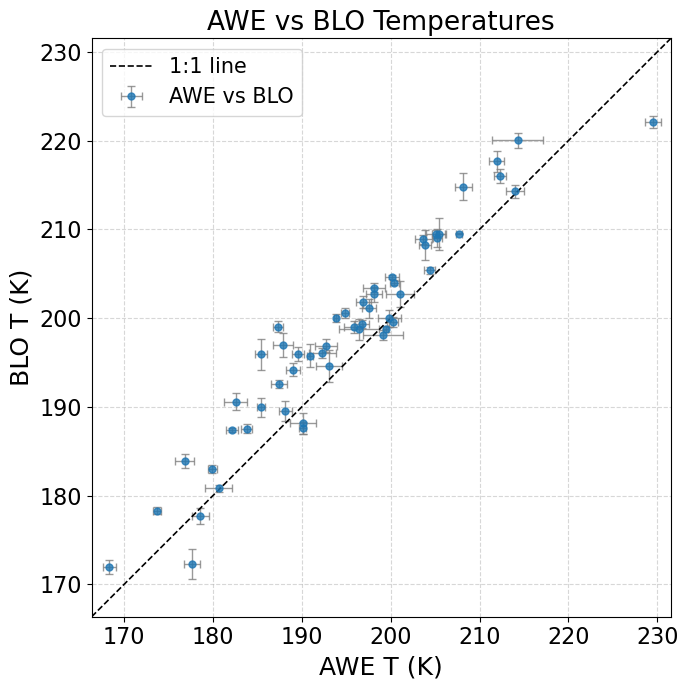

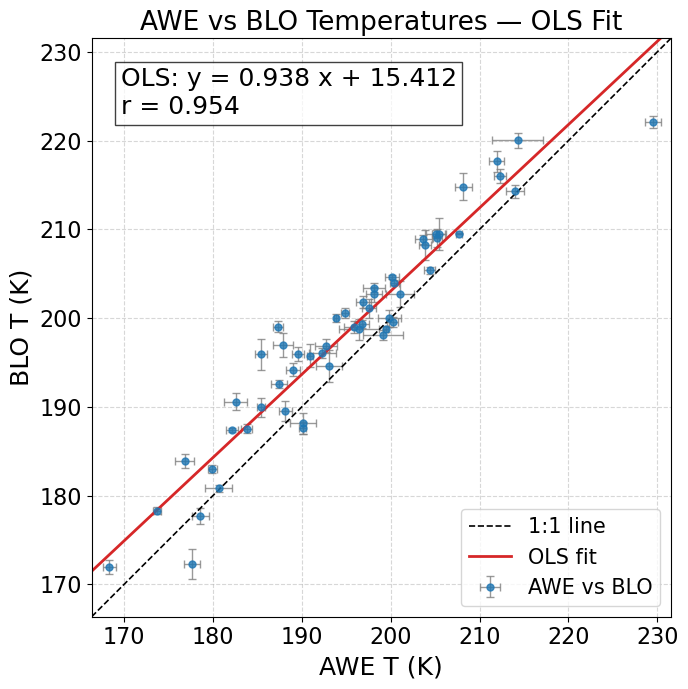

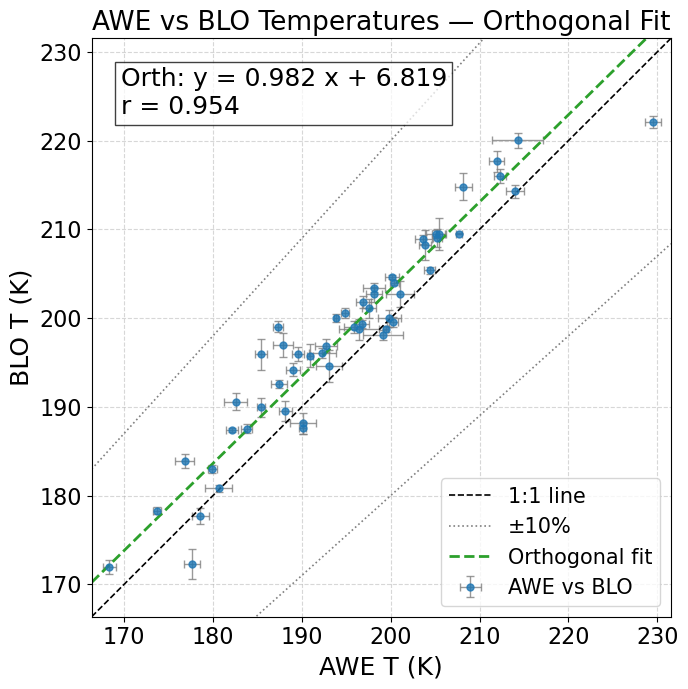

In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
BLO vs AWE AMTM temperature comparison

- Uses "Comparison temperatures_BLO AMTM vs AWE AMTM.csv"
- x-axis: AWE temperatures
- y-axis: BLO temperatures
- Plots:
    1) Scatter with std as crosses
    2) OLS fit (minimize vertical distance dy)
    3) Orthogonal fit (Total Least Squares, minimize perpendicular distance)
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# --------------------- helpers ---------------------
def orthogonal_fit(x, y):
    """
    Total Least Squares / Orthogonal regression line y = m x + b
    minimizing perpendicular distance.
    Returns slope, intercept. If it fails, returns (nan, nan).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    x_fit = x[mask]
    y_fit = y[mask]

    x_mean = x_fit.mean()
    y_mean = y_fit.mean()

    # Center data
    X = np.vstack((x_fit - x_mean, y_fit - y_mean)).T  # shape (N, 2)

    # SVD
    try:
        _, _, vt = np.linalg.svd(X, full_matrices=False)
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    # The direction of smallest variance (normal to line)
    a, b = vt[-1]  # normal vector (a, b) so that a*(x-x_mean)+b*(y-y_mean) = 0

    if np.abs(b) < 1e-12:
        # Vertical line case; cannot express as y = m x + c
        return np.nan, np.nan

    slope = -a / b
    intercept = y_mean - slope * x_mean
    return slope, intercept


def format_line(label, slope, intercept):
    """
    Return 'label: y = m x ± b' with correct sign on b.
    """
    if not np.isfinite(slope) or not np.isfinite(intercept):
        return f"{label}: y = NaN"
    sign = "+" if intercept >= 0 else "-"
    return f"{label}: y = {slope:.3f} x {sign} {abs(intercept):.3f}"


# --------------------- load BLO vs AMTM comparison ---------------------
csv_path = Path("Comparison temperatures_BLO AMTM vs AWE AMTM.csv")
df_blo = pd.read_csv(csv_path)

# Columns in the file:
# 'BLO Temp', 'BLO STD', 'AWE Temp', 'AWE STD'
# Put AWE on x-axis, BLO on y-axis
x = df_blo["AWE Temp"].values      # AMTM (AWE) temperatures
y = df_blo["BLO Temp"].values      # BLO temperatures
x_std = df_blo["AWE STD"].values
y_std = df_blo["BLO STD"].values

# Basic stats + OLS fit
mask = np.isfinite(x) & np.isfinite(y)
if np.sum(mask) >= 2:
    slope_ols, intercept_ols = np.polyfit(x[mask], y[mask], 1)
    r = np.corrcoef(x[mask], y[mask])[0, 1]
else:
    slope_ols, intercept_ols, r = np.nan, np.nan, np.nan

# Orthogonal fit
slope_tls, intercept_tls = orthogonal_fit(x, y)

# Global range for all plots
lo = min(np.nanmin(x), np.nanmin(y)) - 2
hi = max(np.nanmax(x), np.nanmax(y)) + 2
x_line = np.linspace(lo, hi, 200)

# Output directory
out_dir = csv_path.parent
out_dir.mkdir(exist_ok=True, parents=True)

plt.rcParams.update({
    "font.size": 17,
    "axes.labelsize": 18,
    "axes.titlesize": 19,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
})

# --------------------- 1) Scatter with std shown as crosses ---------------------
plt.figure(figsize=(7.2, 7.2))

# "Cross" = errorbars in x and y
plt.errorbar(
    x, y,
    xerr=x_std, yerr=y_std,
    fmt="o", markersize=5,
    ecolor="gray", elinewidth=1.0, capsize=3,
    alpha=0.8, label="AWE vs BLO"
)

plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.2, label="1:1 line")

plt.xlabel("AWE T (K)")
plt.ylabel("BLO T (K)")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("AWE vs BLO Temperatures")
plt.legend(loc="best", framealpha=0.8)

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_BLO_with_std.png", dpi=300)
plt.show()
plt.close()

# --------------------- 2) OLS fit plot ---------------------
plt.figure(figsize=(7.2, 7.2))

plt.errorbar(
    x, y,
    xerr=x_std, yerr=y_std,
    fmt="o", markersize=5,
    ecolor="gray", elinewidth=1.0, capsize=3,
    alpha=0.8, label="AWE vs BLO"
)

plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.2, label="1:1 line")

if np.isfinite(slope_ols) and np.isfinite(intercept_ols):
    y_ols = slope_ols * x_line + intercept_ols
    plt.plot(x_line, y_ols, color="tab:red", linewidth=2.0, label="OLS fit")
    eq_text = format_line("OLS", slope_ols, intercept_ols)
    if np.isfinite(r):
        eq_text += f"\nr = {r:.3f}"
    plt.text(
        0.05, 0.95, eq_text,
        transform=plt.gca().transAxes,
        fontsize=18,
        va="top",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
    )

plt.xlabel("AWE T (K)")
plt.ylabel("BLO T (K)")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("AWE vs BLO Temperatures — OLS Fit")
plt.legend(loc="lower right", framealpha=0.8)

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_BLO_OLS_fit.png", dpi=300)
plt.show()
plt.close()

# --------------------- 3) Orthogonal fit plot ---------------------
plt.figure(figsize=(7.2, 7.2))

plt.errorbar(
    x, y,
    xerr=x_std, yerr=y_std,
    fmt="o", markersize=5,
    ecolor="gray", elinewidth=1.0, capsize=3,
    alpha=0.8, label="AWE vs BLO"
)

# 1:1 line
plt.plot([lo, hi], [lo, hi], "--", color="black",
         linewidth=1.2, label="1:1 line")

plt.plot([lo, hi], [0.9 * lo, 0.9 * hi],
         ":", color="gray", linewidth=1.2)

plt.plot([lo, hi], [1.1 * lo, 1.1 * hi],
         ":", color="gray", linewidth=1.2,
         label="±10%")

if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
    y_tls = slope_tls * x_line + intercept_tls
    plt.plot(
        x_line, y_tls,
        color="tab:green", linestyle="--", linewidth=2.0,
        label="Orthogonal fit"
    )

    eq_text = format_line("Orth", slope_tls, intercept_tls)
    if np.isfinite(r):
        eq_text += f"\nr = {r:.3f}"

    plt.text(
        0.05, 0.95,
        eq_text,
        transform=plt.gca().transAxes,
        fontsize=18,
        va="top",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
    )

plt.xlabel("AWE T (K)")
plt.ylabel("BLO T (K)")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("AWE vs BLO Temperatures — Orthogonal Fit")
plt.legend(loc="lower right", framealpha=0.8)

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_BLO_orthogonal_fit.png", dpi=300)
plt.show()
plt.close()


## Add Uncertainty

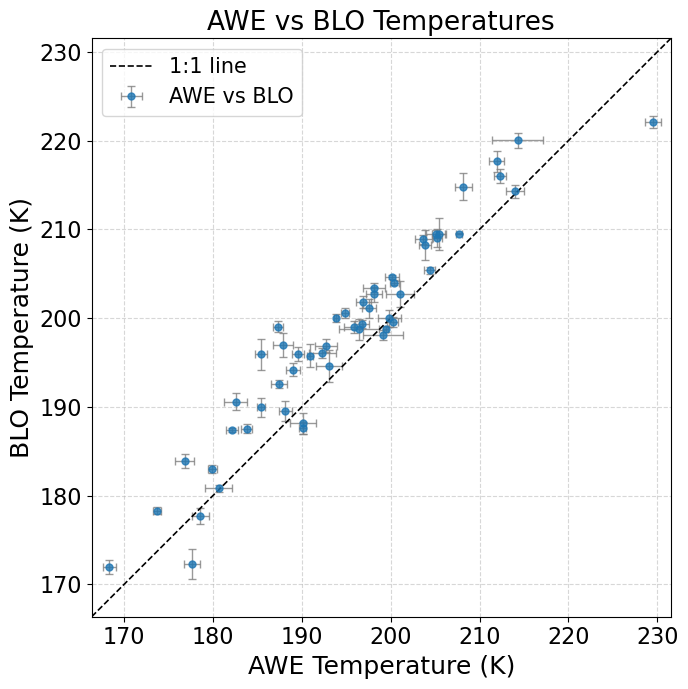

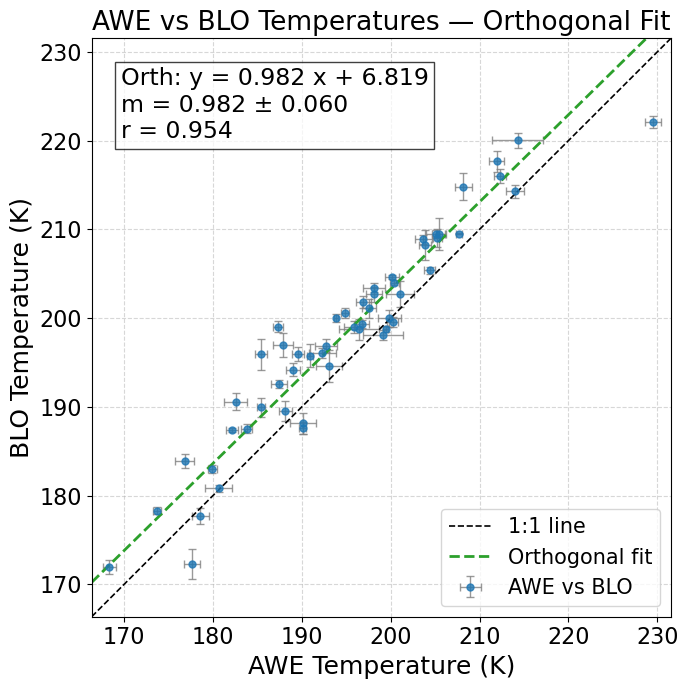


✅ Plots saved to: .
✅ Summary CSV saved to: summary_BLO_vs_AWE_orthogonal_bootstrap.csv

Tiny fit summary table:


,Slope,Slope_SE,Intercept_K,Intercept_SE_K,Slope_CI_low,Slope_CI_high,Intercept_CI_low_K,Intercept_CI_high_K
0,0.9823,0.0602,6.819,11.7542,0.876,1.1047,-17.5393,27.668


In [8]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
BLO vs AWE AMTM temperature comparison
Orthogonal fit only + bootstrap uncertainty

- Uses "Comparison temperatures_BLO AMTM vs AWE AMTM.csv"
- x-axis: AWE temperatures
- y-axis: BLO temperatures
- Plots:
    1) Scatter with std as crosses
    2) Orthogonal fit only (Total Least Squares)
- Bootstrap uncertainty for orthogonal slope/intercept
- Saves summary CSV
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------- user settings ---------------------
CSV_PATH = "Comparison temperatures_BLO AMTM vs AWE AMTM.csv"
N_BOOT = 2000
BOOT_RANDOM_SEED = 0

# --------------------- helpers ---------------------
def orthogonal_fit(x, y):
    """
    Total Least Squares / Orthogonal regression line y = m x + b
    minimizing perpendicular distance.
    Returns slope, intercept. If it fails, returns (nan, nan).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    x_fit = x[mask]
    y_fit = y[mask]

    x_mean = x_fit.mean()
    y_mean = y_fit.mean()

    # Center data
    X = np.vstack((x_fit - x_mean, y_fit - y_mean)).T

    # SVD
    try:
        _, _, vt = np.linalg.svd(X, full_matrices=False)
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    # normal vector to line
    a, b = vt[-1]

    if np.abs(b) < 1e-12:
        return np.nan, np.nan

    slope = -a / b
    intercept = y_mean - slope * x_mean
    return slope, intercept


def orthogonal_fit_bootstrap(x, y, n_boot=2000, random_seed=0):
    """
    Bootstrap uncertainty for orthogonal fit y = m x + b.

    Returns
    -------
    slope, intercept : best-fit values from full sample
    slope_se, intercept_se : bootstrap standard errors
    slope_ci, intercept_ci : 95% bootstrap confidence intervals
    """
    rng = np.random.default_rng(random_seed)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)

    slope, intercept = orthogonal_fit(x, y)

    slopes = []
    intercepts = []
    n = len(x)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)   # resample matched pairs with replacement
        xb = x[idx]
        yb = y[idx]
        m, b = orthogonal_fit(xb, yb)
        if np.isfinite(m) and np.isfinite(b):
            slopes.append(m)
            intercepts.append(b)

    slopes = np.asarray(slopes, dtype=float)
    intercepts = np.asarray(intercepts, dtype=float)

    if len(slopes) < 5 or len(intercepts) < 5:
        return slope, intercept, np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)

    slope_se = np.nanstd(slopes, ddof=1)
    intercept_se = np.nanstd(intercepts, ddof=1)

    slope_ci = (np.nanpercentile(slopes, 2.5), np.nanpercentile(slopes, 97.5))
    intercept_ci = (np.nanpercentile(intercepts, 2.5), np.nanpercentile(intercepts, 97.5))

    return slope, intercept, slope_se, intercept_se, slope_ci, intercept_ci


def format_line(label, slope, intercept):
    """
    Return 'label: y = m x ± b' with correct sign on b.
    """
    if not np.isfinite(slope) or not np.isfinite(intercept):
        return f"{label}: y = NaN"
    sign = "+" if intercept >= 0 else "-"
    return f"{label}: y = {slope:.3f} x {sign} {abs(intercept):.3f}"


# --------------------- load data ---------------------
csv_path = Path(CSV_PATH)
df_blo = pd.read_csv(csv_path)

# Expected columns:
# 'BLO Temp', 'BLO STD', 'AWE Temp', 'AWE STD'
x = df_blo["AWE Temp"].values
y = df_blo["BLO Temp"].values
x_std = df_blo["AWE STD"].values
y_std = df_blo["BLO STD"].values

mask = np.isfinite(x) & np.isfinite(y)
n_total = np.sum(mask)

if n_total >= 2:
    r = np.corrcoef(x[mask], y[mask])[0, 1]
else:
    r = np.nan

(
    slope_tls, intercept_tls,
    slope_tls_se, intercept_tls_se,
    slope_tls_ci, intercept_tls_ci
) = orthogonal_fit_bootstrap(
    x, y,
    n_boot=N_BOOT,
    random_seed=BOOT_RANDOM_SEED
)

# Global range for plots
lo = min(np.nanmin(x), np.nanmin(y)) - 2
hi = max(np.nanmax(x), np.nanmax(y)) + 2
x_line = np.linspace(lo, hi, 200)

# Output directory
out_dir = csv_path.parent
out_dir.mkdir(exist_ok=True, parents=True)

plt.rcParams.update({
    "font.size": 17,
    "axes.labelsize": 18,
    "axes.titlesize": 19,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
})

# --------------------- 1) Scatter with std shown as crosses ---------------------
plt.figure(figsize=(7.2, 7.2))

plt.errorbar(
    x, y,
    xerr=x_std, yerr=y_std,
    fmt="o", markersize=5,
    ecolor="gray", elinewidth=1.0, capsize=3,
    alpha=0.8, label="AWE vs BLO"
)

plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.2, label="1:1 line")

plt.xlabel("AWE Temperature (K)")
plt.ylabel("BLO Temperature (K)")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("AWE vs BLO Temperatures")
plt.legend(loc="best", framealpha=0.8)

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_BLO_with_std.png", dpi=300)
plt.show()
plt.close()

# --------------------- 2) Orthogonal fit plot only ---------------------
plt.figure(figsize=(7.2, 7.2))

plt.errorbar(
    x, y,
    xerr=x_std, yerr=y_std,
    fmt="o", markersize=5,
    ecolor="gray", elinewidth=1.0, capsize=3,
    alpha=0.8, label="AWE vs BLO"
)

plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.2, label="1:1 line")

if np.isfinite(slope_tls) and np.isfinite(intercept_tls):
    y_tls = slope_tls * x_line + intercept_tls
    plt.plot(
        x_line, y_tls,
        color="tab:green", linestyle="--", linewidth=2.0,
        label="Orthogonal fit"
    )

    eq_lines = [
        format_line("Orth", slope_tls, intercept_tls),
    ]
    if np.isfinite(slope_tls_se):
        eq_lines.append(f"m = {slope_tls:.3f} ± {slope_tls_se:.3f}")
    if np.isfinite(r):
        eq_lines.append(f"r = {r:.3f}")

    plt.text(
        0.05, 0.95,
        "\n".join(eq_lines),
        transform=plt.gca().transAxes,
        fontsize=17,
        va="top",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
    )

plt.xlabel("AWE Temperature (K)")
plt.ylabel("BLO Temperature (K)")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("AWE vs BLO Temperatures — Orthogonal Fit")
plt.legend(loc="lower right", framealpha=0.8)

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_BLO_orthogonal_fit_bootstrap.png", dpi=300)
plt.show()
plt.close()

# --------------------- summary CSV ---------------------
summary_row = {
    "N": n_total,
    "corr_AWE_BLO": r,
    "slope_TLS_BLO_vs_AWE": slope_tls,
    "intercept_TLS": intercept_tls,
    "slope_TLS_bootstrap_SE": slope_tls_se,
    "intercept_TLS_bootstrap_SE": intercept_tls_se,
    "slope_TLS_CI_low_95": slope_tls_ci[0],
    "slope_TLS_CI_high_95": slope_tls_ci[1],
    "intercept_TLS_CI_low_95": intercept_tls_ci[0],
    "intercept_TLS_CI_high_95": intercept_tls_ci[1],
}

summary_df = pd.DataFrame([summary_row])
summary_csv = out_dir / "summary_BLO_vs_AWE_orthogonal_bootstrap.csv"
summary_df.to_csv(summary_csv, index=False)

print(f"\n✅ Plots saved to: {out_dir}")
print(f"✅ Summary CSV saved to: {summary_csv}")

# --------------------- tiny follow-up table ---------------------
fit_table = summary_df[[
    "slope_TLS_BLO_vs_AWE",
    "slope_TLS_bootstrap_SE",
    "intercept_TLS",
    "intercept_TLS_bootstrap_SE",
    "slope_TLS_CI_low_95",
    "slope_TLS_CI_high_95",
    "intercept_TLS_CI_low_95",
    "intercept_TLS_CI_high_95",
]].copy()

fit_table = fit_table.rename(columns={
    "slope_TLS_BLO_vs_AWE": "Slope",
    "slope_TLS_bootstrap_SE": "Slope_SE",
    "intercept_TLS": "Intercept_K",
    "intercept_TLS_bootstrap_SE": "Intercept_SE_K",
    "slope_TLS_CI_low_95": "Slope_CI_low",
    "slope_TLS_CI_high_95": "Slope_CI_high",
    "intercept_TLS_CI_low_95": "Intercept_CI_low_K",
    "intercept_TLS_CI_high_95": "Intercept_CI_high_K",
})

print("\nTiny fit summary table:")
display(fit_table.round(4))

## Lidar vs AWE

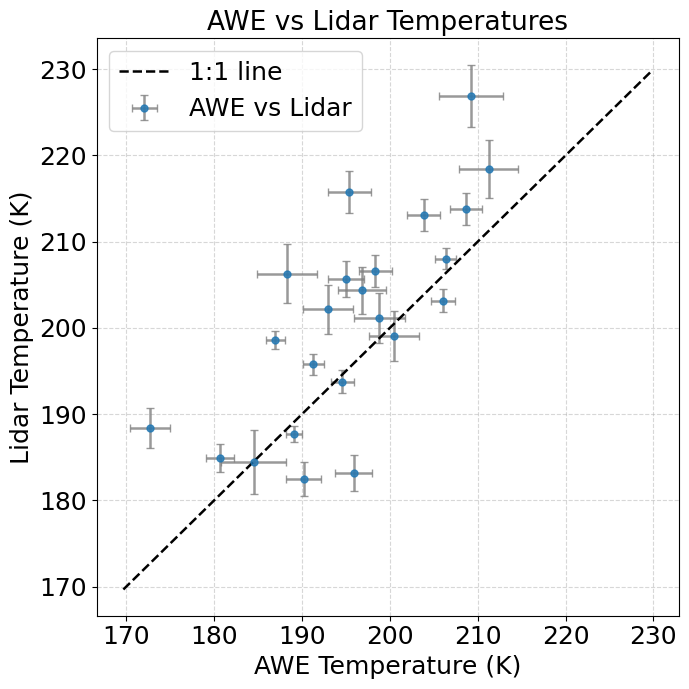

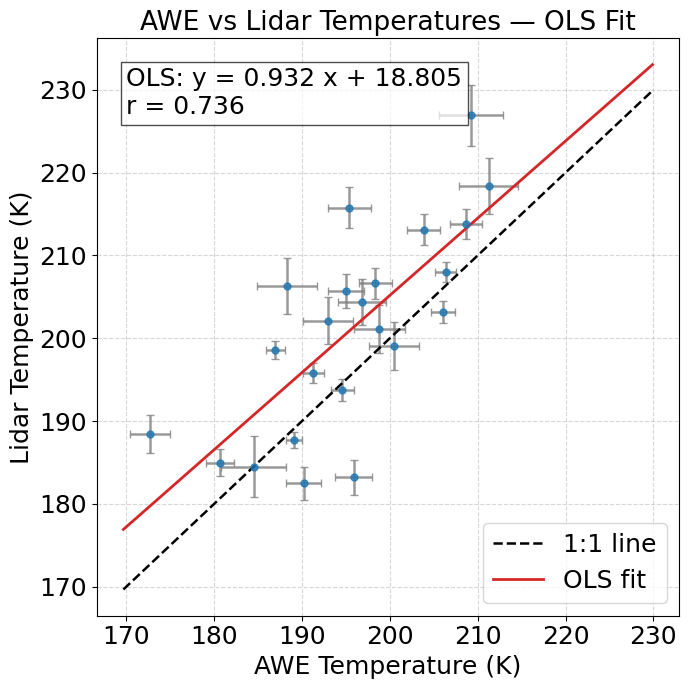

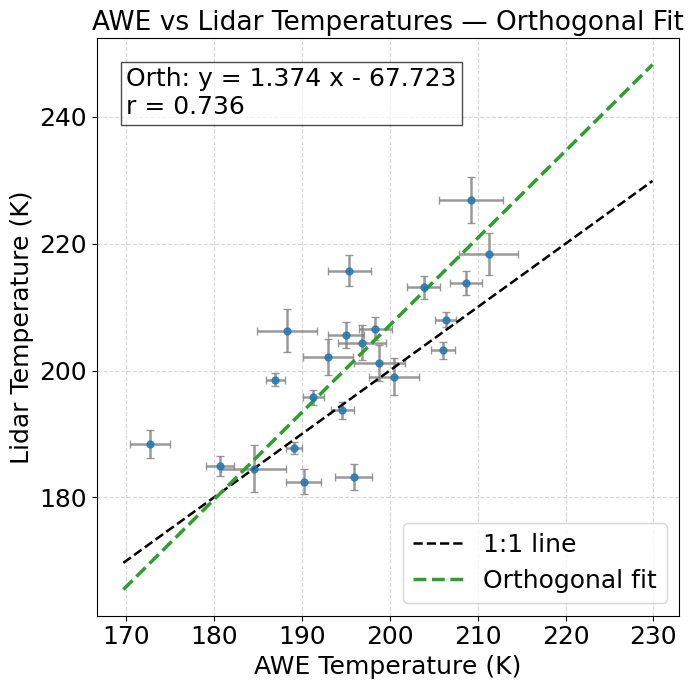

In [7]:
# %%
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------- Helper: format slope/intercept ---------------------
def format_line(label, slope, intercept):
    """
    Return a string like: 'label: y = m x ± b' with correct sign for b.
    Example:
        slope = 1.23, intercept = -4.56  →  "label: y = 1.230 x - 4.560"
    """
    if not np.isfinite(slope) or not np.isfinite(intercept):
        return f"{label}: y = NaN"
    sign = "+" if intercept >= 0 else "-"
    return f"{label}: y = {slope:.3f} x {sign} {abs(intercept):.3f}"


# --------------------- Orthogonal regression helper ---------------------
def orthogonal_fit(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    x_fit, y_fit = x[mask], y[mask]
    xm, ym = x_fit.mean(), y_fit.mean()
    X = np.vstack((x_fit - xm, y_fit - ym)).T

    try:
        _, _, vt = np.linalg.svd(X, full_matrices=False)
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    a, b = vt[-1]  # normal vector to regression line
    if abs(b) < 1e-12:
        return np.nan, np.nan

    slope = -a / b
    intercept = ym - slope * xm
    return slope, intercept


# --------------------- Load CSV file ---------------------
csv_path = Path("lidar-AWE_Modi.csv")
df = pd.read_csv(csv_path)

# Required columns: AWE_Mean, Lidar_Mean, AWE_STD
x = df["AWE_Mean"].to_numpy()
y = df["Lidar_Mean"].to_numpy()
std = df["AWE_STD"].to_numpy()

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(std)
x, y, std = x[mask], y[mask], std[mask]

# --------------------- Fits ---------------------
if np.sum(mask) >= 2:
    slope_ols, intercept_ols = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0, 1]
else:
    slope_ols, intercept_ols, r = np.nan, np.nan, np.nan

slope_tls, intercept_tls = orthogonal_fit(x, y)

# --------------------- Plot range ---------------------
lo = min(np.nanmin(x), np.nanmin(y)) - 3
hi = max(np.nanmax(x), np.nanmax(y)) + 3
x_line = np.linspace(lo, hi, 200)

out_dir = csv_path.parent

plt.rcParams.update({
    "font.size": 17,
    "axes.labelsize": 18,
    "axes.titlesize": 19,
})


# --------------------- 1) Scatter with STD crosses ---------------------
plt.figure(figsize=(7.2, 7.2))
plt.errorbar(
    x, y, xerr=std, yerr=std,
    fmt="o", markersize=5,
    ecolor="gray", capsize=3, alpha=0.8,
    label="AWE vs Lidar"
)
plt.plot([lo, hi], [lo, hi], "--", color="black", label="1:1 line")

plt.xlabel("AWE Temperature (K)")
plt.ylabel("Lidar Temperature (K)")
plt.title("AWE vs Lidar Temperatures")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_Lidar_with_std.png", dpi=300)
plt.show()
plt.close()


# --------------------- 2) OLS fit plot ---------------------
plt.figure(figsize=(7.2, 7.2))
plt.errorbar(
    x, y, xerr=std, yerr=std,
    fmt="o", markersize=5, ecolor="gray",
    capsize=3, alpha=0.8
)
plt.plot([lo, hi], [lo, hi], "--", color="black", label="1:1 line")

if np.isfinite(slope_ols):
    plt.plot(
        x_line, slope_ols * x_line + intercept_ols,
        color="tab:red", linewidth=2.0, label="OLS fit"
    )

    eq_text = (
        format_line("OLS", slope_ols, intercept_ols)
        + f"\nr = {r:.3f}"
    )

    plt.text(
        0.05, 0.95,
        eq_text,
        transform=plt.gca().transAxes,
        va="top", fontsize=18,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
    )

plt.xlabel("AWE Temperature (K)")
plt.ylabel("Lidar Temperature (K)")
plt.title("AWE vs Lidar Temperatures — OLS Fit")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_Lidar_OLS_fit.png", dpi=300)
plt.show()
plt.close()


# --------------------- 3) Orthogonal fit plot ---------------------
plt.figure(figsize=(7.2, 7.2))
plt.errorbar(
    x, y, xerr=std, yerr=std,
    fmt="o", markersize=5, ecolor="gray",
    capsize=3, alpha=0.8
)
plt.plot([lo, hi], [lo, hi], "--", color="black", label="1:1 line")

if np.isfinite(slope_tls):
    plt.plot(
        x_line, slope_tls * x_line + intercept_tls,
        color="tab:green", linestyle="--", linewidth=2.5,
        label="Orthogonal fit"
    )

    eq_text = (
        format_line("Orth", slope_tls, intercept_tls)
        + f"\nr = {r:.3f}"
    )

    plt.text(
        0.05, 0.95,
        eq_text,
        transform=plt.gca().transAxes,
        va="top", fontsize=18,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
    )

plt.xlabel("AWE Temperature (K)")
plt.ylabel("Lidar Temperature (K)")
plt.title("AWE vs Lidar Temperatures — Orthogonal Fit")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_Lidar_orthogonal_fit.png", dpi=300)
plt.show()
plt.close()


## Add Uncertainty

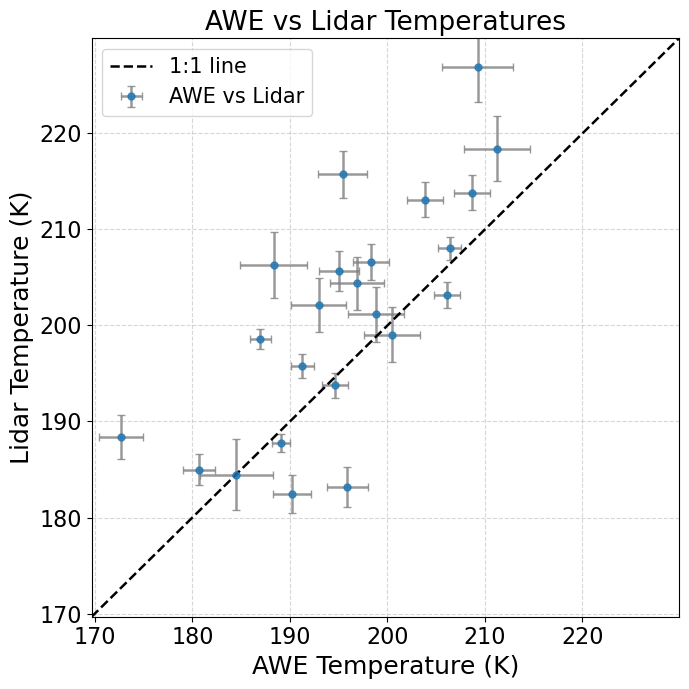

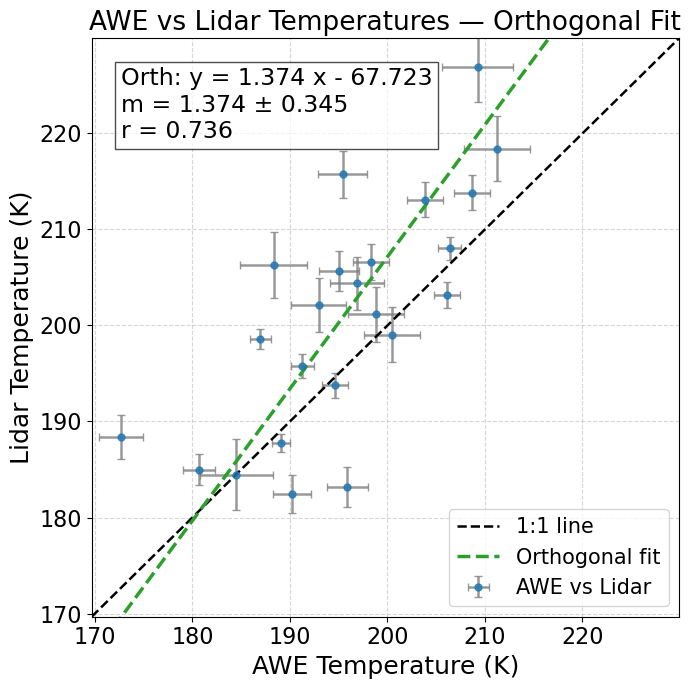


✅ Plots saved to: .
✅ Summary CSV saved to: summary_AWE_vs_Lidar_orthogonal_bootstrap.csv

Tiny fit summary table:


,Slope,Slope_SE,Intercept_K,Intercept_SE_K,Slope_CI_low,Slope_CI_high,Intercept_CI_low_K,Intercept_CI_high_K
0,1.3744,0.3453,-67.7226,68.0698,0.9081,2.219,-233.6294,24.0126


In [9]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
AWE vs Lidar temperature comparison
Orthogonal fit only + bootstrap uncertainty

- Uses "lidar-AWE_Modi.csv"
- x-axis: AWE temperatures
- y-axis: Lidar temperatures
- Plots:
    1) Scatter with std as crosses
    2) Orthogonal fit only (Total Least Squares)
- Bootstrap uncertainty for orthogonal slope/intercept
- Saves summary CSV
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------- user settings ---------------------
CSV_PATH = "lidar-AWE_Modi.csv"
N_BOOT = 2000
BOOT_RANDOM_SEED = 0

# --------------------- Helper: format slope/intercept ---------------------
def format_line(label, slope, intercept):
    """
    Return a string like: 'label: y = m x ± b' with correct sign for b.
    """
    if not np.isfinite(slope) or not np.isfinite(intercept):
        return f"{label}: y = NaN"
    sign = "+" if intercept >= 0 else "-"
    return f"{label}: y = {slope:.3f} x {sign} {abs(intercept):.3f}"

# --------------------- Orthogonal regression helper ---------------------
def orthogonal_fit(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    x_fit, y_fit = x[mask], y[mask]
    xm, ym = x_fit.mean(), y_fit.mean()
    X = np.vstack((x_fit - xm, y_fit - ym)).T

    try:
        _, _, vt = np.linalg.svd(X, full_matrices=False)
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    a, b = vt[-1]  # normal vector to regression line
    if abs(b) < 1e-12:
        return np.nan, np.nan

    slope = -a / b
    intercept = ym - slope * xm
    return slope, intercept

def orthogonal_fit_bootstrap(x, y, n_boot=2000, random_seed=0):
    """
    Bootstrap uncertainty for orthogonal fit y = m x + b.

    Returns
    -------
    slope, intercept : best-fit values from full sample
    slope_se, intercept_se : bootstrap standard errors
    slope_ci, intercept_ci : 95% bootstrap confidence intervals
    """
    rng = np.random.default_rng(random_seed)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)

    slope, intercept = orthogonal_fit(x, y)

    slopes = []
    intercepts = []
    n = len(x)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)   # resample matched pairs with replacement
        xb = x[idx]
        yb = y[idx]
        m, b = orthogonal_fit(xb, yb)
        if np.isfinite(m) and np.isfinite(b):
            slopes.append(m)
            intercepts.append(b)

    slopes = np.asarray(slopes, dtype=float)
    intercepts = np.asarray(intercepts, dtype=float)

    if len(slopes) < 5 or len(intercepts) < 5:
        return slope, intercept, np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)

    slope_se = np.nanstd(slopes, ddof=1)
    intercept_se = np.nanstd(intercepts, ddof=1)

    slope_ci = (np.nanpercentile(slopes, 2.5), np.nanpercentile(slopes, 97.5))
    intercept_ci = (np.nanpercentile(intercepts, 2.5), np.nanpercentile(intercepts, 97.5))

    return slope, intercept, slope_se, intercept_se, slope_ci, intercept_ci

# --------------------- Load CSV file ---------------------
csv_path = Path(CSV_PATH)
df = pd.read_csv(csv_path)

# Required columns: AWE_Mean, Lidar_Mean, AWE_STD
x = df["AWE_Mean"].to_numpy()
y = df["Lidar_Mean"].to_numpy()
std = df["AWE_STD"].to_numpy()

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(std)
x, y, std = x[mask], y[mask], std[mask]

n_total = len(x)
if n_total >= 2:
    r = np.corrcoef(x, y)[0, 1]
else:
    r = np.nan

(
    slope_tls, intercept_tls,
    slope_tls_se, intercept_tls_se,
    slope_tls_ci, intercept_tls_ci
) = orthogonal_fit_bootstrap(
    x, y,
    n_boot=N_BOOT,
    random_seed=BOOT_RANDOM_SEED
)

# --------------------- Plot range ---------------------
lo = min(np.nanmin(x), np.nanmin(y)) - 3
hi = max(np.nanmax(x), np.nanmax(y)) + 3
x_line = np.linspace(lo, hi, 200)

out_dir = csv_path.parent

plt.rcParams.update({
    "font.size": 17,
    "axes.labelsize": 18,
    "axes.titlesize": 19,
})

# --------------------- 1) Scatter with STD crosses ---------------------
plt.figure(figsize=(7.2, 7.2))
plt.errorbar(
    x, y, xerr=std, yerr=std,
    fmt="o", markersize=5,
    ecolor="gray", capsize=3, alpha=0.8,
    label="AWE vs Lidar"
)
plt.plot([lo, hi], [lo, hi], "--", color="black", label="1:1 line")

plt.xlabel("AWE Temperature (K)")
plt.ylabel("Lidar Temperature (K)")
plt.title("AWE vs Lidar Temperatures")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_Lidar_with_std.png", dpi=300)
plt.show()
plt.close()

# --------------------- 2) Orthogonal fit plot only ---------------------
plt.figure(figsize=(7.2, 7.2))
plt.errorbar(
    x, y, xerr=std, yerr=std,
    fmt="o", markersize=5, ecolor="gray",
    capsize=3, alpha=0.8,
    label="AWE vs Lidar"
)
plt.plot([lo, hi], [lo, hi], "--", color="black", label="1:1 line")

if np.isfinite(slope_tls):
    plt.plot(
        x_line, slope_tls * x_line + intercept_tls,
        color="tab:green", linestyle="--", linewidth=2.5,
        label="Orthogonal fit"
    )

    eq_lines = [
        format_line("Orth", slope_tls, intercept_tls)
    ]
    if np.isfinite(slope_tls_se):
        eq_lines.append(f"m = {slope_tls:.3f} ± {slope_tls_se:.3f}")
    if np.isfinite(r):
        eq_lines.append(f"r = {r:.3f}")

    plt.text(
        0.05, 0.95,
        "\n".join(eq_lines),
        transform=plt.gca().transAxes,
        va="top", fontsize=17,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
    )

plt.xlabel("AWE Temperature (K)")
plt.ylabel("Lidar Temperature (K)")
plt.title("AWE vs Lidar Temperatures — Orthogonal Fit")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(out_dir / "AWE_vs_Lidar_orthogonal_fit_bootstrap.png", dpi=300)
plt.show()
plt.close()

# --------------------- summary CSV ---------------------
summary_row = {
    "N": n_total,
    "corr_AWE_Lidar": r,
    "slope_TLS_Lidar_vs_AWE": slope_tls,
    "intercept_TLS": intercept_tls,
    "slope_TLS_bootstrap_SE": slope_tls_se,
    "intercept_TLS_bootstrap_SE": intercept_tls_se,
    "slope_TLS_CI_low_95": slope_tls_ci[0],
    "slope_TLS_CI_high_95": slope_tls_ci[1],
    "intercept_TLS_CI_low_95": intercept_tls_ci[0],
    "intercept_TLS_CI_high_95": intercept_tls_ci[1],
}

summary_df = pd.DataFrame([summary_row])
summary_csv = out_dir / "summary_AWE_vs_Lidar_orthogonal_bootstrap.csv"
summary_df.to_csv(summary_csv, index=False)

print(f"\n✅ Plots saved to: {out_dir}")
print(f"✅ Summary CSV saved to: {summary_csv}")

# --------------------- tiny follow-up table ---------------------
fit_table = summary_df[[
    "slope_TLS_Lidar_vs_AWE",
    "slope_TLS_bootstrap_SE",
    "intercept_TLS",
    "intercept_TLS_bootstrap_SE",
    "slope_TLS_CI_low_95",
    "slope_TLS_CI_high_95",
    "intercept_TLS_CI_low_95",
    "intercept_TLS_CI_high_95",
]].copy()

fit_table = fit_table.rename(columns={
    "slope_TLS_Lidar_vs_AWE": "Slope",
    "slope_TLS_bootstrap_SE": "Slope_SE",
    "intercept_TLS": "Intercept_K",
    "intercept_TLS_bootstrap_SE": "Intercept_SE_K",
    "slope_TLS_CI_low_95": "Slope_CI_low",
    "slope_TLS_CI_high_95": "Slope_CI_high",
    "intercept_TLS_CI_low_95": "Intercept_CI_low_K",
    "intercept_TLS_CI_high_95": "Intercept_CI_high_K",
})

print("\nTiny fit summary table:")
display(fit_table.round(4))